#Project Initialization & Environment Setup

###The initialization process includes:

* **Clone the Project Repository:** We use `git clone` to fetch the primary codebase from the official `llm-as-a-judge-praktikum` repository into our current workspace.

* **Clone the Shared-Task Dataset:** We download the benchmark dataset repository (`wmt-mist`) which contains the evaluations and test data needed for this specific task.

* **Install Dependencies:** Finally, we run `pip install -r requirements.txt` to automatically install all necessary Python packages and libraries, ensuring a fully compatible and error-free execution environment.


In [2]:
!git clone https://github.com/NhAnh278/llm-as-a-judge-praktikum.git

Cloning into 'llm-as-a-judge-praktikum'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 121 (delta 69), reused 23 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (121/121), 2.36 MiB | 3.74 MiB/s, done.
Resolving deltas: 100% (69/69), done.


In [3]:
!git clone https://github.com/wmt-conference/wmt-mist.git

Cloning into 'wmt-mist'...
remote: Enumerating objects: 165, done.
remote: Total 165 (delta 0), reused 0 (delta 0), pack-reused 165 (from 1)
Receiving objects: 100% (165/165), 199.31 MiB | 16.14 MiB/s, done.
Resolving deltas: 100% (69/69), done.
Updating files: 100% (83/83), done.


In [4]:
%cd llm-as-a-judge-praktikum

/content/llm-as-a-judge-praktikum


In [5]:
!pip install -r requirements.txt

# Week 1 Summary: (human-rating) Dataset Loading & Exploratory Data Analysis (EDA)

During the first week, the primary focus was on loading the human-rating evaluation dataset and conducting a thorough Exploratory Data Analysis (EDA) to understand its structural properties, distribution, and core metrics.

In [6]:
%cd ..
%cd wmt-mist

/content
/content/wmt-mist


In [7]:
#load file human ratings
import json
import pandas as pd
from pathlib import Path

human_path = Path("data/humeval/oeg.json")
judge_dir = Path("data/submissions_judge_oeg")
mist_path = Path("data/mist_25.json")
with open(human_path, "r", encoding="utf-8") as f:
  human_data = json.load(f)
type(human_data), len(human_data)

(list, 7360)

In [8]:
#convert all data into DataFrame
df_human = pd.DataFrame(human_data)
df_human.head()

,system,prompt,response,doc_id,language_locale,coherence,naturalness,instruction_following,mean_score,rater,language
0,Gemma-3-12B,إنت ممثل خدمة عملا في شركة تكنولوجيا. عميل كلم...,أهلاً بك [اسم العميل]،<br><br>شكرًا لك على الا...,104373856e995a074579797ebe34fcb2,Egyptian Arabic,7.0,1.0,7.0,5.000000,rater1_ar_EG,ar_EG
1,Gemma-3-12B,من فضلكم، أنا بتلقى رسائل إلكترونية دعائية بشك...,تمام، هذا طلب رسمي ومهم جدًا. إليك صيغة مُحسّن...,fb2c387e7e5272a43305940219116463,Egyptian Arabic,6.0,5.0,6.0,5.666667,rater2_ar_EG,ar_EG
2,Mistral-Medium,صاحبك القريب منك مسافر برة البلد ومتوتر إنه هي...,**عزيزي صديقي،**<br><br>أعلم أن هذه اللحظة ملي...,e91353a8c4dde03994b2cbfb5521172e,Egyptian Arabic,5.0,1.0,5.0,3.666667,rater2_ar_EG,ar_EG
3,Qwen3-235B,اكتب حوار بالمصري بين اتنين صحاب، واحد فيهم بي...,**[موقف: صحابين قاعدين في الكافيتيريا، واحد من...,170d490a7ae53347e8fe3eabe4e28001,Egyptian Arabic,7.0,4.0,7.0,6.000000,rater3_ar_EG,ar_EG
4,CommandR7B,أنا سكنت مؤخرًا في سكن طلاب. لاحظت إن واحد من ...,يمكنك كتابة ملحوظة لزقة على النحو التالي:<br><...,14e076d13751e87d8c09f7f13125e755,Egyptian Arabic,7.0,1.0,7.0,5.000000,rater3_ar_EG,ar_EG


In [9]:
df_human.shape

(7360, 11)

In [10]:
df_human.columns

Index(['system', 'prompt', 'response', 'doc_id', 'language_locale',
       'coherence', 'naturalness', 'instruction_following', 'mean_score',
       'rater', 'language'],
      dtype='object')

###1. Dataset Dimensions & Schema
The dataset was successfully loaded into a pandas DataFrame. Initial inspection reveals a well-structured and clean schema:
* **Shape:** `(7360, 11)` — The dataset contains **7,360 rows** (evaluation samples) and **11 columns** (features).
* **Column Inventory:** `['system', 'prompt', 'response', 'doc_id', 'language_locale', 'coherence', 'naturalness', 'instruction_following', 'mean_score', 'rater', 'language']`



In [11]:
df_human[[
    "coherence",
    "naturalness",
    "instruction_following",
    "mean_score"
]].describe()
#score is between 1 and 7
#naturalness has a lowest mean
#instruction_following looks really good with the highest mean score
#generally, human ratings are really high

,coherence,naturalness,instruction_following,mean_score
count,7360.000000,7360.000000,7360.000000,7360.000000
mean,5.790217,5.347554,5.869973,5.669248
std,1.588282,1.789316,1.496409,1.419300
min,1.000000,1.000000,1.000000,1.000000
25%,5.000000,5.000000,5.000000,5.000000
50%,7.000000,6.000000,7.000000,6.000000
75%,7.000000,7.000000,7.000000,7.000000
max,7.000000,7.000000,7.000000,7.000000


###2. Statistical Summary of Human Ratings
The dataset contains human quality scores across three primary dimensions (`coherence`, `naturalness`, `instruction_following`), alongside a final consolidated `mean_score`. All metrics are rated on a **1 to 7 scale**.


**Key Insight:** The distribution of scores is skewed toward higher quality, with median scores sitting at `6.0` or `7.0`. Models generally perform best at *Instruction Following* (Mean: 5.87) and struggle slightly more with *Naturalness* (Mean: 5.35).

In [12]:
df_human["system"].value_counts()

,count
system,
Gemma-3-12B,460
Mistral-Medium,460
Qwen3-235B,460
CommandR7B,460
Llama-3,460
DeepSeek-V3,460
Mistral-7B,460
AyaExpanse-32B,460
Claude-4,460


In [13]:
df_human["language_locale"].value_counts()

,count
language_locale,
Egyptian Arabic,736
English (United States),736
German (Germany),736
Simplified Chinese (China),736
Hindi (India),736
Czech (Czechia),736
Indonesian (Indonesia),736
Japanese (Japan),736
Russian (Russia),736


###3. Linguistic & Geographic Distribution
There are exactly **736 samples per locale** across **10 distinct linguistic regions**:

* 🇪🇬 **Egyptian Arabic** (736)
* 🇺🇸 **English** (United States) (736)
* 🇩🇪 **German** (Germany) (736)
* 🇨🇳 **Simplified Chinese** (China) (736)
* 🇮🇳 **Hindi** (India) (736)
* 🇨🇿 **Czech** (Czechia) (736)
* 🇮🇩 **Indonesian** (Indonesia) (736)
* 🇯🇵 **Japanese** (Japan) (736)
* 🇷🇺 **Russian** (Russia) (736)
* 🇧🇩 **Bangla** (Bangladesh) (736)


the shared task dataset contains :

- 7360 rows
- 46 doc_id
- 10 languages
- 16 systems
- 460 unique prompts

so we have:
46 doc_id × 10 languages × 16 systems = 7360 rows

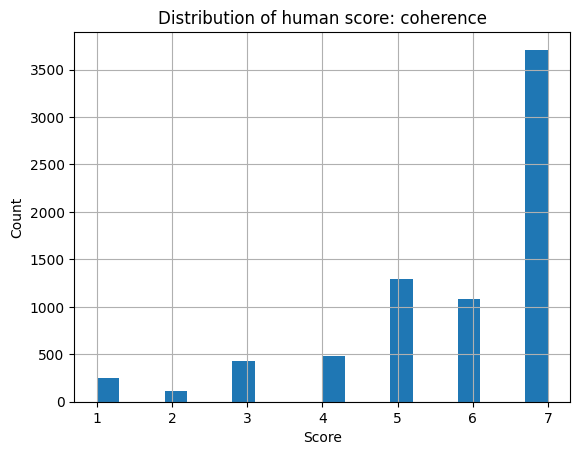

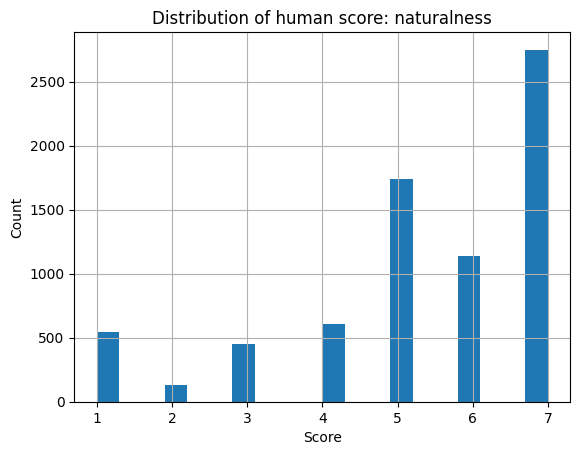

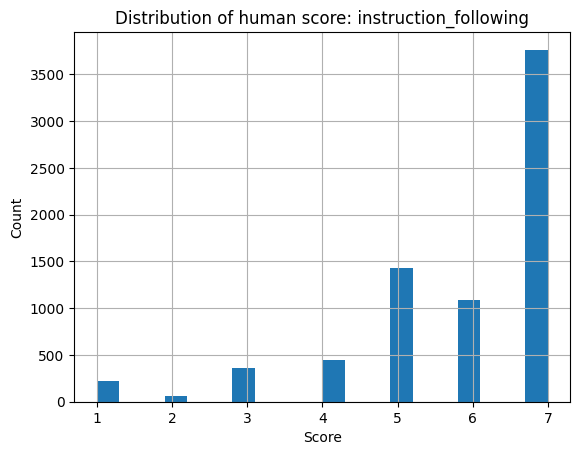

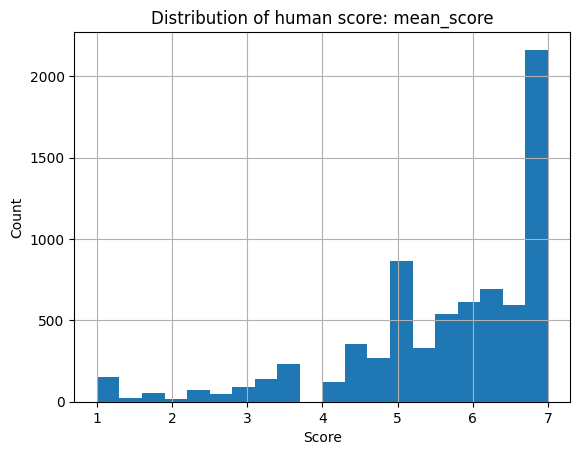

In [14]:
#plot human scores per aspect
score_cols = [
    "coherence",
    "naturalness",
    "instruction_following",
    "mean_score"
]

import matplotlib.pyplot as plt

for col in score_cols:
  plt.figure()
  df_human[col].hist(bins=20)
  plt.title(f"Distribution of human score: {col}")
  plt.xlabel("Score")
  plt.ylabel("Count")
  plt.show()

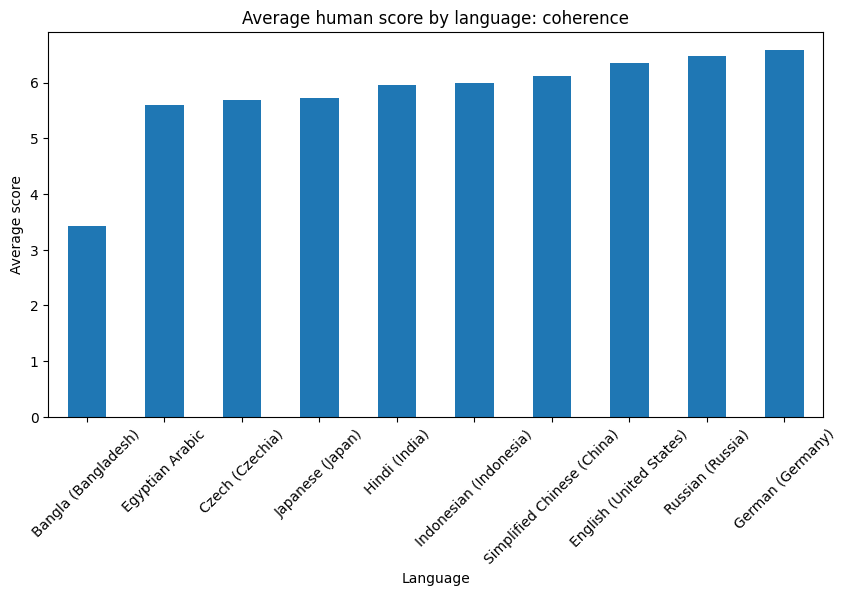

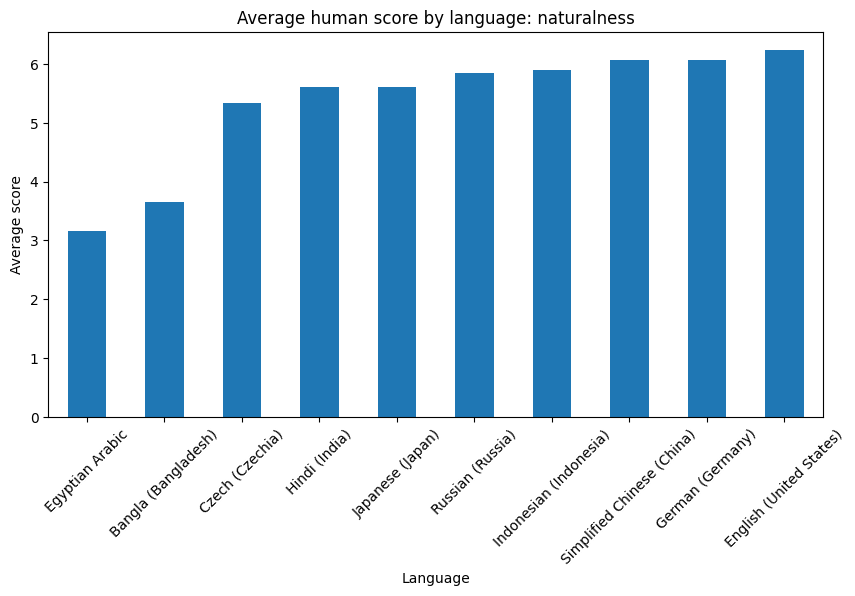

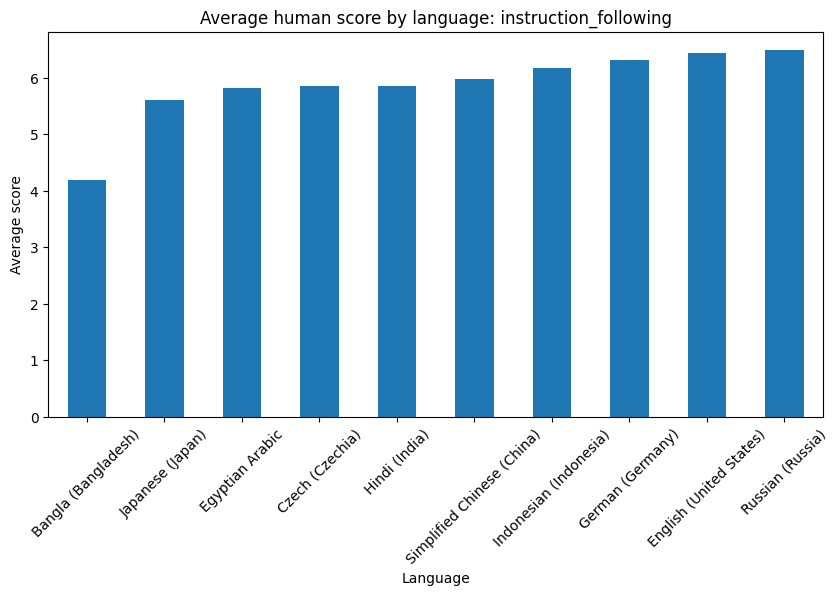

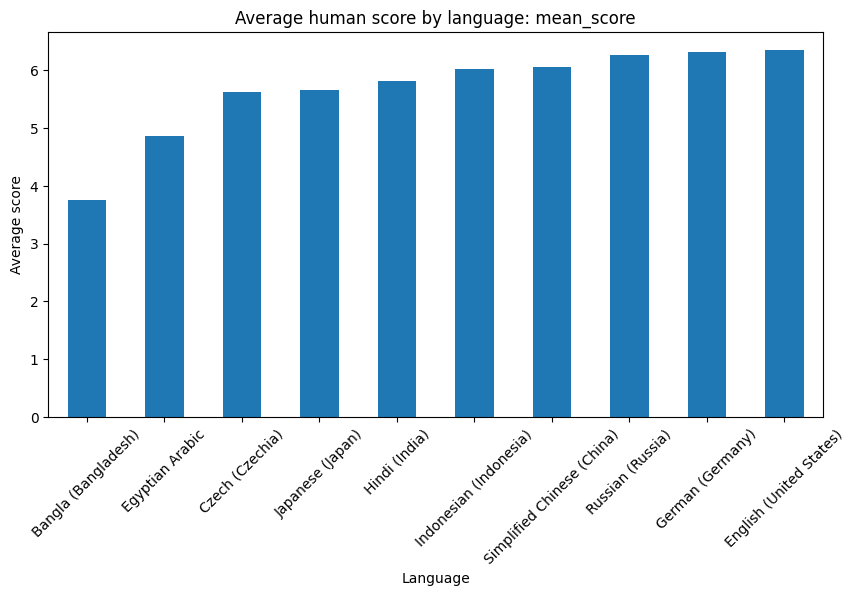

In [15]:
#Plot score per language
for col in score_cols:
    lang_scores = df_human.groupby("language_locale")[col].mean().sort_values()

    plt.figure(figsize=(10, 5))
    lang_scores.plot(kind="bar")
    plt.title(f"Average human score by language: {col}")
    plt.xlabel("Language")
    plt.ylabel("Average score")
    plt.xticks(rotation=45)
    plt.show()

###4. Deep-Dive Visual Data Analysis

To better understand the human evaluation behavior, we generated distribution plots for each quality metric and analyzed how performance varies across different languages.



####A. Score Distributions (Histograms)
Looking at the distribution of scores across the four criteria, we notice a clear **positivity bias** in human annotations:

* **Coherence & Instruction Following:** These two metrics exhibit the strongest left-skewed distribution. The vast majority of the 7,360 evaluations are concentrated at a score of `7` (over 3,500 samples each), meaning human raters found the generated responses highly logical and compliant with the initial prompts.
* **Naturalness:** While still heavily skewed toward higher scores, `naturalness` shows a more spread-out distribution compared to coherence. The bar for a score of `5` is significantly higher here, indicating that generating truly fluent, native-sounding text across all languages remains a slightly harder task for the evaluated systems.
* **Mean Score:** Combining all dimensions creates a smoother, multi-modal distribution that peaks sharply at `7`, with secondary clusters around the integer values `5` and `6`.


####B. Language-Specific Performance Breakdown (Bar Charts)
Analyzing the average human score grouped by language reveals interesting cross-lingual variations and identifies where language models struggle the most:

| Metric | Highest Performing Languages | Lowest Performing Languages |
| :--- | :--- | :--- |
| **Coherence** | German, Russian, English (`~6.5`) | Bangla (`~3.4`), Egyptian Arabic (`~5.6`) |
|**Naturalness** | English, German, Simplified Chinese (`>6.0`) | Egyptian Arabic (`~3.2`), Bangla (`~3.6`) |
|**Instruction Following** | Russian, English, German (`~6.5`) | Bangla (`~4.2`), Japanese, Egyptian Arabic (`~5.6`) |
|**Overall Mean Score** | English, German, Russian (`>6.0`) | Bangla (`~3.8`), Egyptian Arabic (`~4.9`) |

####Critical Observations & Data Insights:
1. **The Western-Language Dominance:** Across all four sub-plots, **English (US)**, **German**, and **Russian** consistently anchor the top 3 positions with the highest average scores. This indicates that the underlying generative models are highly mature in high-resource, Western languages.
2. **The Bangla Bottleneck:** **Bangla (Bangladesh)** is a prominent outlier across almost every chart, particularly in *Coherence* and *Overall Mean Score* where its average sits below `4.0`. This reveals a severe performance gap, suggesting either a low-resource limitation in the evaluated systems or stricter grading criteria from the Bangla human raters.
3. **The Localized Dialect Challenge:** While Standard Arabic datasets usually perform moderately well, **Egyptian Arabic** scores exceptionally low in *Naturalness* (`~3.2`). This demonstrates the classic difficulty language models face when dealing with colloquial dialectal variants versus Modern Standard Arabic (MSA).

In [16]:
#average human score by model
score_cols = ["coherence", "naturalness", "instruction_following", "mean_score"]

model_scores = (
    df_human
    .groupby("system")[score_cols]
    .mean()
    .sort_values("mean_score", ascending=False)
)

model_scores

,coherence,naturalness,instruction_following,mean_score
system,,,,
GPT-4,6.200000,5.936957,6.239130,6.125362
Gemini-2,6.215217,5.797826,6.247826,6.086957
DeepSeek-V3,6.091304,5.645652,6.169565,5.968841
Claude-4,6.082609,5.741304,6.056522,5.960145
Mistral-Medium,6.032609,5.680435,6.158696,5.957246
Gemma-3-27B,6.065217,5.591304,6.152174,5.936232
CommandA,6.028261,5.645652,6.119565,5.931159
Qwen3-235B,5.993478,5.565217,6.134783,5.897826
Llama-4-Maverick,5.930435,5.734783,6.017391,5.894203


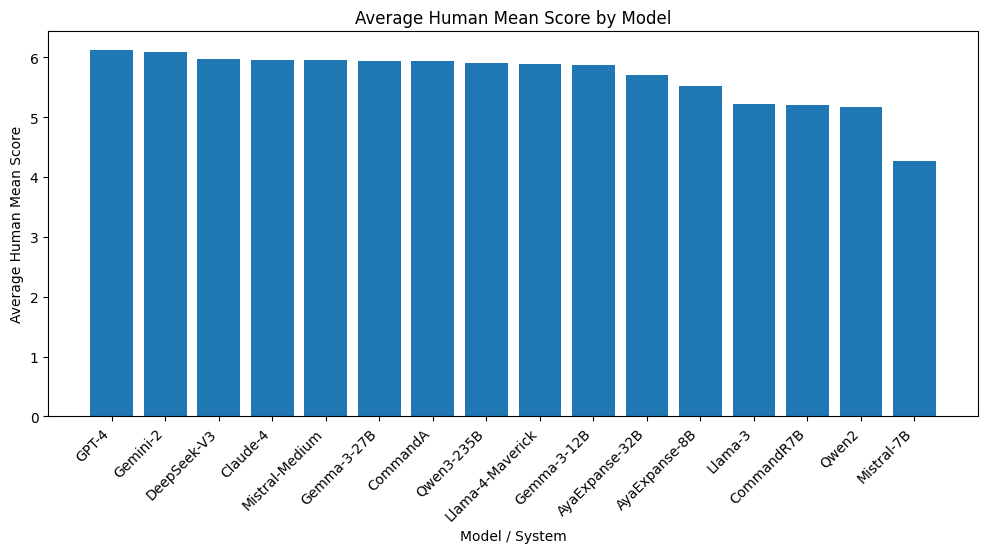

In [17]:
#plot mean_score by models
model_mean = (
    df_human
    .groupby("system")["mean_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
plt.bar(model_mean.index, model_mean.values)
plt.title("Average Human Mean Score by Model")
plt.xlabel("Model / System")
plt.ylabel("Average Human Mean Score")
plt.xticks(rotation=45, ha="right")
plt.show()

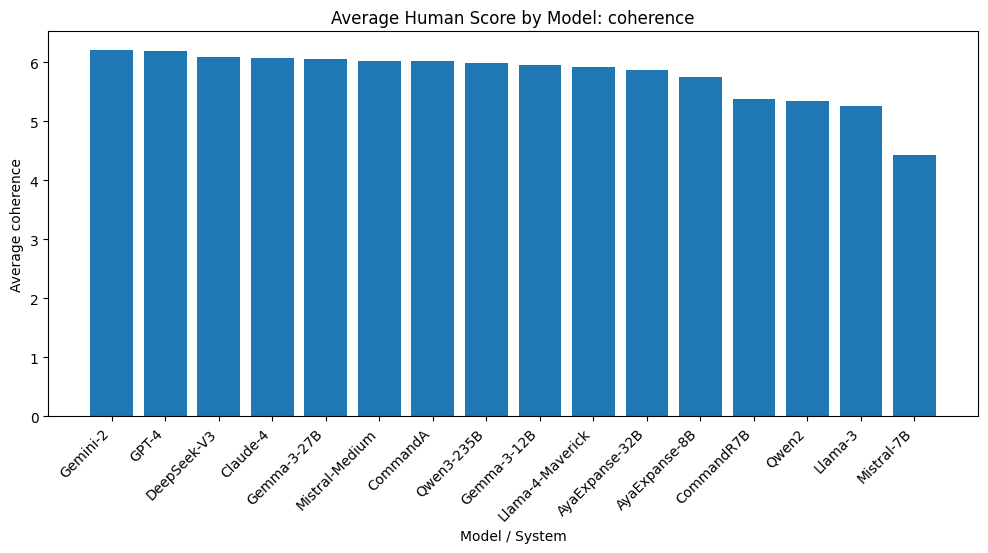

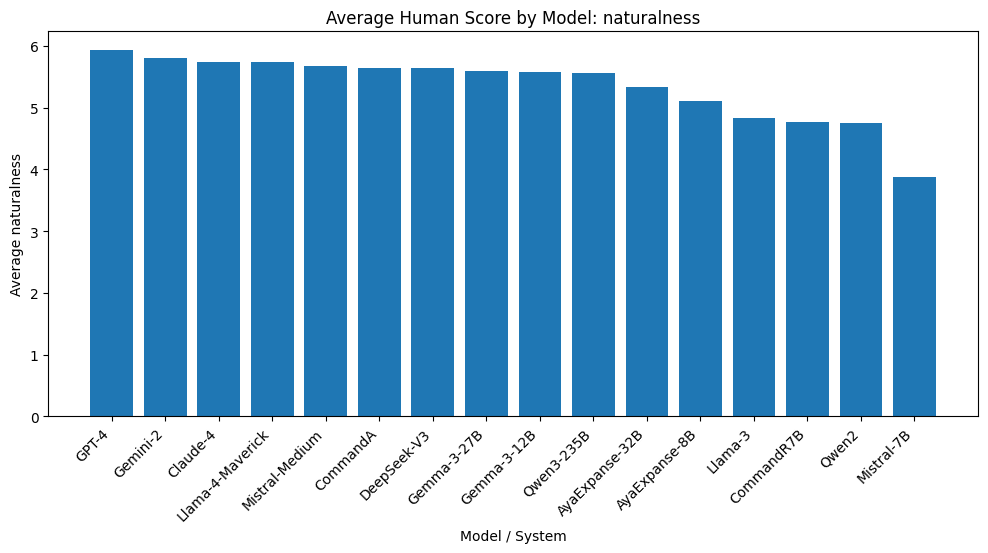

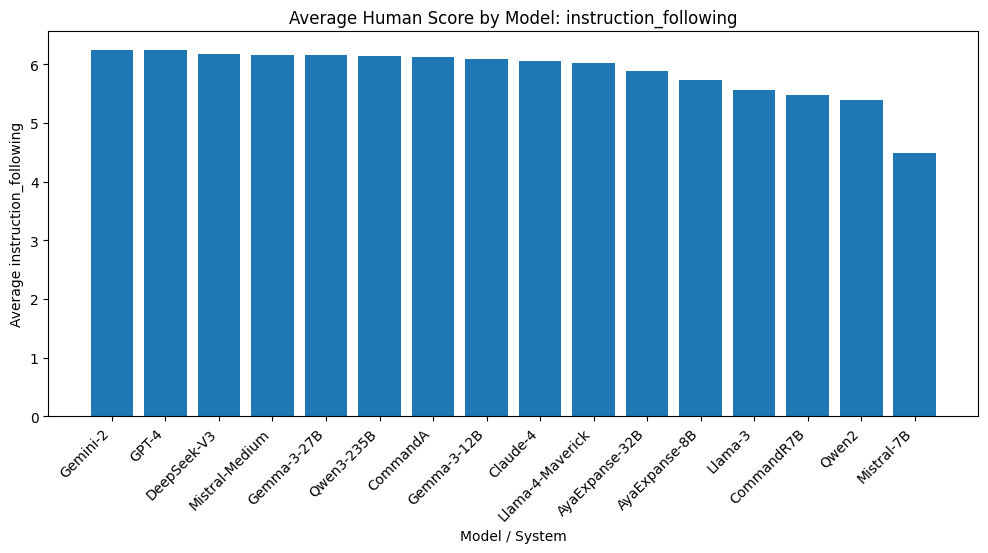

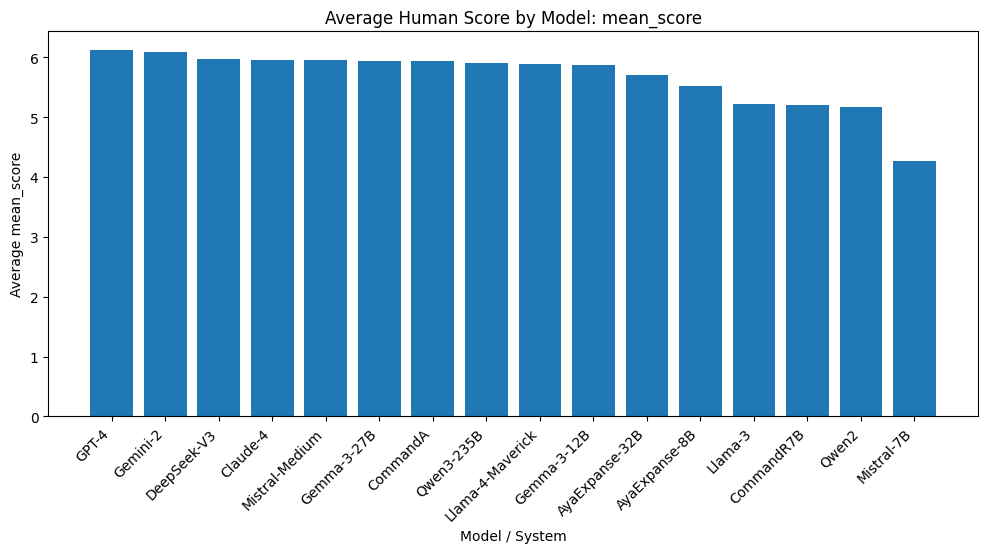

In [18]:
#plot for every aspect by models
for col in score_cols:
    model_scores_aspect = (
        df_human
        .groupby("system")[col]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 5))
    plt.bar(model_scores_aspect.index, model_scores_aspect.values)
    plt.title(f"Average Human Score by Model: {col}")
    plt.xlabel("Model / System")
    plt.ylabel(f"Average {col}")
    plt.xticks(rotation=45, ha="right")
    plt.show()

###5. Summary of Human Evaluation Results by Model

#### High-performing models

The top models generally receive scores close to or above **5.9** in `mean_score`. This indicates that their responses are usually considered coherent, natural, and well aligned with the given instructions by human annotators.

Examples of strong systems include:

- **GPT-4**
- **Gemini-2**
- **DeepSeek-V3**
- **Claude-4**
- **Mistral-Medium**

#### Lower-performing models

On the other hand, **Llama-3**, **CommandR7B**, **Qwen2**, and especially **Mistral-7B** receive noticeably lower human scores. Among all evaluated systems, **Mistral-7B** performs the weakest across every aspect, with a much lower overall mean score than the other models.


#Week 2: Load judge model rating data

In [19]:
#prepare human rating dataset with segment to merge later

#load mist to get segment_id
with open(mist_path, "r", encoding="utf-8") as f:
    mist_data = json.load(f)

df_mist = pd.DataFrame(mist_data)

df_mist_oeg = df_mist[
    df_mist["taskid"].str.startswith("open_ended_generation", na=False)
].copy()

#parse doc_id and segment_id
prefix = "open_ended_generation_"

df_mist_oeg["doc_segment"] = df_mist_oeg["taskid"].str.replace(prefix, "", regex=False)

df_mist_oeg["doc_id"] = df_mist_oeg["doc_segment"].str.rsplit("_", n=1).str[0]
df_mist_oeg["segment_id"] = df_mist_oeg["doc_segment"].str.rsplit("_", n=1).str[1]

df_mist_oeg[["taskid", "doc_id", "segment_id", "prompt"]].head()


#create segment_map
df_segment_map = df_mist_oeg[
    ["doc_id", "segment_id", "prompt"]
].drop_duplicates()


#merge segment_id into human data
df_human_with_segment = df_human.merge(
    df_segment_map,
    on=["doc_id", "prompt"],
    how="left"
)

print("Missing segment_id:", df_human_with_segment["segment_id"].isna().sum())

#drop unmatch row
df_human_with_segment_clean = df_human_with_segment.dropna(
    subset=["segment_id"]
).copy()

print("Before:", len(df_human_with_segment))
print("After:", len(df_human_with_segment_clean))
print("Dropped:", len(df_human_with_segment) - len(df_human_with_segment_clean))


Missing segment_id: 16
Before: 7360
After: 7344
Dropped: 16


In [20]:
# convert human ratings to long format
score_cols = ["coherence", "naturalness", "instruction_following", "mean_score"]

df_human_long = df_human_with_segment_clean.melt(
    id_vars=[
        "doc_id",
        "segment_id",
        "system",
        "language",
        "language_locale",
        "prompt",
        "response"
    ],
    value_vars=score_cols,
    var_name="aspect",
    value_name="human_score"
)

df_human_long["segment_id"] = df_human_long["segment_id"].astype(int).astype(str)

df_human_long.head()

,doc_id,segment_id,system,language,language_locale,prompt,response,aspect,human_score
0,104373856e995a074579797ebe34fcb2,293,Gemma-3-12B,ar_EG,Egyptian Arabic,إنت ممثل خدمة عملا في شركة تكنولوجيا. عميل كلم...,أهلاً بك [اسم العميل]،<br><br>شكرًا لك على الا...,coherence,7.0
1,e91353a8c4dde03994b2cbfb5521172e,298,Mistral-Medium,ar_EG,Egyptian Arabic,صاحبك القريب منك مسافر برة البلد ومتوتر إنه هي...,**عزيزي صديقي،**<br><br>أعلم أن هذه اللحظة ملي...,coherence,5.0
2,170d490a7ae53347e8fe3eabe4e28001,288,Qwen3-235B,ar_EG,Egyptian Arabic,اكتب حوار بالمصري بين اتنين صحاب، واحد فيهم بي...,**[موقف: صحابين قاعدين في الكافيتيريا، واحد من...,coherence,7.0
3,14e076d13751e87d8c09f7f13125e755,241,CommandR7B,ar_EG,Egyptian Arabic,أنا سكنت مؤخرًا في سكن طلاب. لاحظت إن واحد من ...,يمكنك كتابة ملحوظة لزقة على النحو التالي:<br><...,coherence,7.0
4,c145f96bc4b6c5d0d18e06e89cb629bd,210,Llama-3,ar_EG,Egyptian Arabic,اكتبلي مونولوج بالمصري، كإنه نهر بيحكي وبيقول ...,(نهر النيل يبدأ بالحديث)<br><br>يا لها من رحلة...,coherence,5.0


In [21]:
human_keys = df_human_with_segment_clean[
    ["doc_id", "segment_id", "system"]
].drop_duplicates()

human_keys["segment_id"] = human_keys["segment_id"].astype(int).astype(str)

human_keys.head()

,doc_id,segment_id,system
0,104373856e995a074579797ebe34fcb2,293,Gemma-3-12B
2,e91353a8c4dde03994b2cbfb5521172e,298,Mistral-Medium
3,170d490a7ae53347e8fe3eabe4e28001,288,Qwen3-235B
4,14e076d13751e87d8c09f7f13125e755,241,CommandR7B
5,c145f96bc4b6c5d0d18e06e89cb629bd,210,Llama-3


In [22]:
%cd ..
%cd llm-as-a-judge-praktikum
from src.utils import load_json, load_data

/content
/content/llm-as-a-judge-praktikum


In [23]:
%cd ..

/content


In [24]:
#load file

judge_dir = Path("wmt-mist/data/submissions_judge_oeg")

df_mistral_7b = load_data(judge_dir / "Mistral-7B.json")
df_qwen2_5_7b = load_data(judge_dir / "Qwen2.5-7B.json")
df_commandr_7b = load_data(judge_dir / "CommandR7B.json")
df_llama_3_1_8b = load_data(judge_dir / "Llama-3.1-8B.json")
df_ayaexpanse_32b = load_data(judge_dir / "AyaExpanse-32B.json")
df_ayaexpanse_8b = load_data(judge_dir / "AyaExpanse-8B.json")
df_claude_4 = load_data(judge_dir / "Claude-4.json")
df_commanda = load_data(judge_dir / "CommandA.json")
df_deepseek_v3 = load_data(judge_dir / "DeepSeek-V3.json")
df_gpt_4_1 = load_data (judge_dir / "GPT-4.1.json")
df_llama_4_maverick = load_data(judge_dir / "Llama-4-Maverick.json")
df_mistral_medium = load_data(judge_dir / "Mistral-Medium.json")
df_qwen_3_235b = load_data(judge_dir / "Qwen3-235B.json")


In [25]:
#process judge data frame function
aspect_map = {
    "judge_it": "instruction_following",
    "judge_coherence": "coherence",
    "judge_natural": "naturalness",
}

def process_judge_df(df_raw, judge_model_name):
    """
    Process one raw judge dataframe.

    Output columns:
    judge_model, doc_id, segment_id, system, aspect, judge_score
    """

    df = df_raw.copy()

    parts = df["taskid"].str.split("_#_", expand=True)

    df["judge_aspect_raw"] = parts[0]
    df["middle"] = parts[1]
    df["system"] = parts[2]

    prefix = "open_ended_generation_"
    df["doc_segment"] = df["middle"].str.replace(prefix, "", regex=False)

    df["doc_id"] = df["doc_segment"].str.rsplit("_", n=1).str[0]
    df["segment_id"] = df["doc_segment"].str.rsplit("_", n=1).str[1]

    df["aspect"] = df["judge_aspect_raw"].map(aspect_map)
    df["judge_score"] = pd.to_numeric(df["answer"], errors="coerce")

    df = df.dropna(subset=["aspect", "judge_score"]).copy()
    df["segment_id"] = df["segment_id"].astype(str)
    df["judge_model"] = judge_model_name

    df = df[
        ["judge_model", "doc_id", "segment_id", "system", "aspect", "judge_score"]
    ].copy()

    # Add judge mean_score = average of 3 judge aspects
    df_mean = (
        df
        .groupby(["judge_model", "doc_id", "segment_id", "system"], as_index=False)["judge_score"]
        .mean()
    )

    df_mean["aspect"] = "mean_score"

    df_with_mean = pd.concat(
        [
            df,
            df_mean[["judge_model", "doc_id", "segment_id", "system", "aspect", "judge_score"]]
        ],
        ignore_index=True
    )

    return df_with_mean

In [26]:
df_mistral_7b = process_judge_df(df_mistral_7b, "mistral_7b")
df_qwen2_5_7b = process_judge_df(df_qwen2_5_7b, "qwen2_5_7b")
df_commandr_7b = process_judge_df(df_commandr_7b, "commandr_7b")
df_llama_3_1_8b = process_judge_df(df_llama_3_1_8b, "llama_3_1_8b")
df_ayaexpanse_32b = process_judge_df(df_ayaexpanse_32b, "ayaexpanse_32b")
df_ayaexpanse_8b = process_judge_df(df_ayaexpanse_8b, "ayaexpanse_8b")
df_claude_4 = process_judge_df(df_claude_4, "claude_4")
df_commanda = process_judge_df(df_commanda, "commanda")
df_deepseek_v3 = process_judge_df(df_deepseek_v3, "deepseek_v3")
df_gpt_4_1 = process_judge_df(df_gpt_4_1, "gpt_4_1")
df_llama_4_maverick = process_judge_df(df_llama_4_maverick, "llama_4_maverick")
df_mistral_medium = process_judge_df(df_mistral_medium, "mistral_medium")
df_qwen_3_235b = process_judge_df(df_qwen_3_235b, "qwen_3_235b")


In [27]:
#function to merge
def merge_judge_with_human(df_judge, df_human_long, human_keys):
    df_judge = df_judge.copy()
    df_human_long = df_human_long.copy()
    human_keys = human_keys.copy()

    df_judge["segment_id"] = df_judge["segment_id"].astype(str)
    df_human_long["segment_id"] = df_human_long["segment_id"].astype(str)
    human_keys["segment_id"] = human_keys["segment_id"].astype(str)

    df_judge_filtered = df_judge.merge(
        human_keys,
        on=["doc_id", "segment_id", "system"],
        how="inner"
    )

    df_merged = df_judge_filtered.merge(
        df_human_long,
        on=["doc_id", "segment_id", "system", "aspect"],
        how="inner"
    )

    print("Judge model:", df_judge["judge_model"].iloc[0])
    print("Judge rows before filtering:", len(df_judge))
    print("Judge rows after filtering:", len(df_judge_filtered))
    print("Merged rows:", len(df_merged))
    print("Merge rate:", len(df_merged) / len(df_judge_filtered))

    return df_merged

In [28]:
#merge
df_mistral_merged = merge_judge_with_human(df_mistral_7b, df_human_long, human_keys)
df_qwen_merged = merge_judge_with_human(df_qwen2_5_7b, df_human_long, human_keys)
df_commandr_merged = merge_judge_with_human(df_commandr_7b, df_human_long, human_keys)
df_llama_merged = merge_judge_with_human(df_llama_3_1_8b, df_human_long, human_keys)
df_ayaexpanse_32b_merged = merge_judge_with_human(df_ayaexpanse_32b, df_human_long, human_keys)
df_ayaexpanse_8b_merged = merge_judge_with_human(df_ayaexpanse_8b, df_human_long, human_keys)
df_claude_4_merged = merge_judge_with_human(df_claude_4, df_human_long, human_keys)
df_commanda_merged = merge_judge_with_human(df_commanda, df_human_long, human_keys)
df_deepseek_v3_merged = merge_judge_with_human(df_deepseek_v3, df_human_long, human_keys)
df_gpt_4_1_merged = merge_judge_with_human(df_gpt_4_1, df_human_long, human_keys)
df_llama_4_maverick_merged = merge_judge_with_human(df_llama_4_maverick, df_human_long, human_keys)
df_mistral_medium_merged = merge_judge_with_human(df_mistral_medium, df_human_long, human_keys)
df_qwen_3_235b_merged = merge_judge_with_human(df_qwen_3_235b, df_human_long, human_keys)


Judge model: mistral_7b
Judge rows before filtering: 30080
Judge rows after filtering: 29376
Merged rows: 29376
Merge rate: 1.0
Judge model: qwen2_5_7b
Judge rows before filtering: 30080
Judge rows after filtering: 29376
Merged rows: 29376
Merge rate: 1.0
Judge model: commandr_7b
Judge rows before filtering: 30080
Judge rows after filtering: 29376
Merged rows: 29376
Merge rate: 1.0
Judge model: llama_3_1_8b
Judge rows before filtering: 30080
Judge rows after filtering: 29376
Merged rows: 29376
Merge rate: 1.0
Judge model: ayaexpanse_32b
Judge rows before filtering: 30080
Judge rows after filtering: 29376
Merged rows: 29376
Merge rate: 1.0
Judge model: ayaexpanse_8b
Judge rows before filtering: 30047
Judge rows after filtering: 29343
Merged rows: 29343
Merge rate: 1.0
Judge model: claude_4
Judge rows before filtering: 30078
Judge rows after filtering: 29374
Merged rows: 29374
Merge rate: 1.0
Judge model: commanda
Judge rows before filtering: 30080
Judge rows after filtering: 29376
Merge

In [29]:
#overall metrics function
from scipy.stats import pearsonr, spearmanr, kendalltau
import numpy as np
def safe_corr(x, y):
    x = pd.Series(x)
    y = pd.Series(y)

    if len(x) < 3:
        return np.nan, np.nan

    if x.nunique() <= 1 or y.nunique() <= 1:
        return np.nan, np.nan

    spearman, _ = spearmanr(x, y)
    pearson, _ = pearsonr(x, y)

    return spearman, pearson

def compute_overall_metrics(df_merged):
    df_eval = df_merged.dropna(subset=["human_score", "judge_score"])

    spearman, pearson = safe_corr(
        df_eval["human_score"],
        df_eval["judge_score"]
    )

    return {
        "judge_model": df_eval["judge_model"].iloc[0],
        "n": len(df_eval),
        "spearman": spearman,
        "pearson": pearson,
        "human_mean": df_eval["human_score"].mean(),
        "judge_mean": df_eval["judge_score"].mean(),
        "judge_minus_human": df_eval["judge_score"].mean() - df_eval["human_score"].mean()
    }

In [30]:
#comput_corelation_function
def compute_corr(df, human_col="human_score", judge_col="judge_score"):
    clean_df = df[[human_col, judge_col]].dropna()

    if len(clean_df) < 3:
        return {
            "n": len(clean_df),
            "spearman": np.nan,
            "pearson": np.nan,
        }

    if clean_df[human_col].nunique() <= 1 or clean_df[judge_col].nunique() <= 1:
        return {
            "n": len(clean_df),
            "spearman": np.nan,
            "pearson": np.nan,
        }

    spearman, _ = spearmanr(clean_df[human_col], clean_df[judge_col])
    pearson, _ = pearsonr(clean_df[human_col], clean_df[judge_col])

    return {
        "n": len(clean_df),
        "spearman": spearman,
        "pearson": pearson,
    }

In [31]:
overall_results = [
    compute_overall_metrics(df_mistral_merged),
    compute_overall_metrics(df_qwen_merged),
    compute_overall_metrics(df_commandr_merged),
    compute_overall_metrics(df_llama_merged),
]

df_overall = pd.DataFrame(overall_results).sort_values(
    "spearman",
    ascending=False
)

df_overall

,judge_model,n,spearman,pearson,human_mean,judge_mean,judge_minus_human
1,qwen2_5_7b,29376,0.177562,0.239224,5.67352,6.170615,0.497095
2,commandr_7b,29376,0.161995,0.223444,5.67352,6.658224,0.984704
0,mistral_7b,29376,0.122386,0.146365,5.67352,6.634622,0.961102
3,llama_3_1_8b,29376,0.089752,0.186079,5.67352,6.014570,0.341049


In [32]:
aspect_results = []

for name, df in [
    ("Mistral-7B", df_mistral_merged),
    ("Qwen2.5-7B", df_qwen_merged),
    ("CommandR7B", df_commandr_merged),
    ("Llama-3.1-8B", df_llama_merged),
]:
    for aspect, group in df.groupby("aspect"):
        corr = compute_corr(group)

        aspect_results.append({
            "judge_model": name,
            "aspect": aspect,
            "n": corr["n"],
            "spearman": corr["spearman"],
            "pearson": corr["pearson"],
            "human_mean": group["human_score"].mean(),
            "judge_mean": group["judge_score"].mean(),
            "judge_minus_human": group["judge_score"].mean() - group["human_score"].mean()
        })

df_by_aspect = pd.DataFrame(aspect_results).sort_values(
    ["aspect", "spearman"],
    ascending=[True, False]
)

df_by_aspect

,judge_model,aspect,n,spearman,pearson,human_mean,judge_mean,judge_minus_human
4,Qwen2.5-7B,coherence,7344,0.232252,0.283878,5.794254,5.946351,0.152097
0,Mistral-7B,coherence,7344,0.146930,0.194808,5.794254,6.567674,0.773420
12,Llama-3.1-8B,coherence,7344,0.137263,0.243763,5.794254,5.842320,0.048066
8,CommandR7B,coherence,7344,0.134824,0.210145,5.794254,6.689815,0.895561
9,CommandR7B,instruction_following,7344,0.215243,0.277422,5.874455,6.578159,0.703704
5,Qwen2.5-7B,instruction_following,7344,0.202272,0.276481,5.874455,6.012255,0.137800
13,Llama-3.1-8B,instruction_following,7344,0.147823,0.219578,5.874455,6.029684,0.155229
1,Mistral-7B,instruction_following,7344,0.097316,0.118741,5.874455,6.764706,0.890251
6,Qwen2.5-7B,mean_score,7344,0.246314,0.341499,5.673520,6.170615,0.497095
10,CommandR7B,mean_score,7344,0.184493,0.285063,5.673520,6.658224,0.984704


In [33]:
language_results = []

for name, df in [
    ("Mistral-7B", df_mistral_merged),
    ("Qwen2.5-7B", df_qwen_merged),
    ("CommandR7B", df_commandr_merged),
    ("Llama-3.1-8B", df_llama_merged),
]:
    for language, group in df.groupby("language_locale"):
        corr = compute_corr(group)

        language_results.append({
            "judge_model": name,
            "language_locale": language,
            "n": corr["n"],
            "spearman": corr["spearman"],
            "pearson": corr["pearson"],
            "human_mean": group["human_score"].mean(),
            "judge_mean": group["judge_score"].mean(),
            "judge_minus_human": group["judge_score"].mean() - group["human_score"].mean()
        })

df_by_language = pd.DataFrame(language_results).sort_values(
    ["language_locale", "spearman"],
    ascending=[True, False]
)

df_by_language

,judge_model,language_locale,n,spearman,pearson,human_mean,judge_mean,judge_minus_human
10,Qwen2.5-7B,Bangla (Bangladesh),2944,0.347616,0.385121,3.756341,5.697464,1.941123
30,Llama-3.1-8B,Bangla (Bangladesh),2944,0.266677,0.366222,3.756341,5.765851,2.009511
20,CommandR7B,Bangla (Bangladesh),2944,0.178346,0.232414,3.756341,6.373641,2.617301
0,Mistral-7B,Bangla (Bangladesh),2944,0.067167,0.112627,3.756341,6.231431,2.475091
21,CommandR7B,Czech (Czechia),2944,0.135445,0.209637,5.624094,6.825181,1.201087
11,Qwen2.5-7B,Czech (Czechia),2944,0.074055,0.128590,5.624094,6.160779,0.536685
1,Mistral-7B,Czech (Czechia),2944,0.018227,0.083674,5.624094,6.758152,1.134058
31,Llama-3.1-8B,Czech (Czechia),2944,-0.024149,0.108991,5.624094,6.064764,0.440670
22,CommandR7B,Egyptian Arabic,2880,0.183309,0.240595,4.878704,6.615278,1.736574
12,Qwen2.5-7B,Egyptian Arabic,2880,0.132260,0.179572,4.878704,6.068519,1.189815


In [34]:
system_results = []

for name, df in [
    ("Mistral-7B", df_mistral_merged),
    ("Qwen2.5-7B", df_qwen_merged),
    ("CommandR7B", df_commandr_merged),
    ("Llama-3.1-8B", df_llama_merged),
]:
    for system, group in df.groupby("system"):
        corr = compute_corr(group)

        system_results.append({
            "judge_model": name,
            "judged_system": system,
            "n": corr["n"],
            "spearman": corr["spearman"],
            "pearson": corr["pearson"],
            "human_mean": group["human_score"].mean(),
            "judge_mean": group["judge_score"].mean(),
            "judge_minus_human": group["judge_score"].mean() - group["human_score"].mean()
        })

df_by_system = pd.DataFrame(system_results).sort_values(
    ["judged_system", "spearman"],
    ascending=[True, False]
)

df_by_system

,judge_model,judged_system,n,spearman,pearson,human_mean,judge_mean,judge_minus_human
16,Qwen2.5-7B,AyaExpanse-32B,1836,0.137486,0.146714,5.708061,6.320988,0.612927
32,CommandR7B,AyaExpanse-32B,1836,0.117741,0.116657,5.708061,6.785040,1.076979
0,Mistral-7B,AyaExpanse-32B,1836,0.106788,0.129739,5.708061,6.759622,1.051561
48,Llama-3.1-8B,AyaExpanse-32B,1836,0.067622,0.057022,5.708061,6.214960,0.506899
17,Qwen2.5-7B,AyaExpanse-8B,1836,0.200577,0.229071,5.525781,6.263617,0.737836
...,...,...,...,...,...,...,...,...
14,Mistral-7B,Qwen2,1836,0.110576,0.129996,5.175744,6.594771,1.419027
47,CommandR7B,Qwen3-235B,1836,0.087985,0.143073,5.899782,6.765432,0.865650
15,Mistral-7B,Qwen3-235B,1836,0.061623,0.062898,5.899782,6.746550,0.846768
31,Qwen2.5-7B,Qwen3-235B,1836,0.046663,0.035826,5.899782,6.459695,0.559913


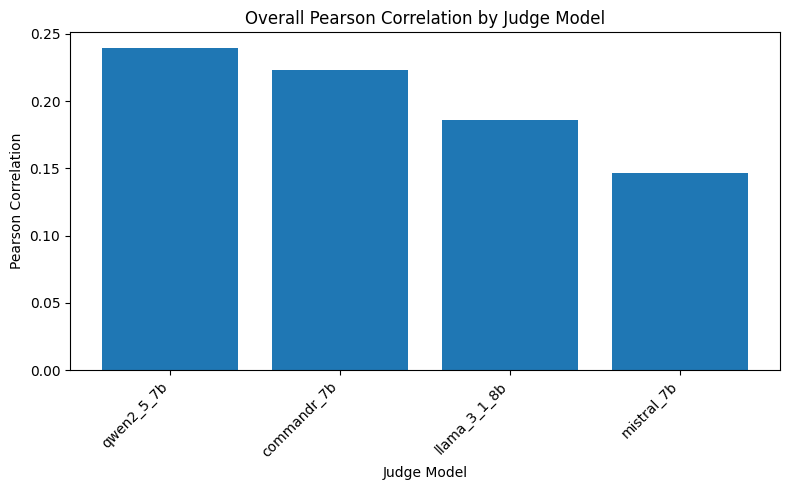

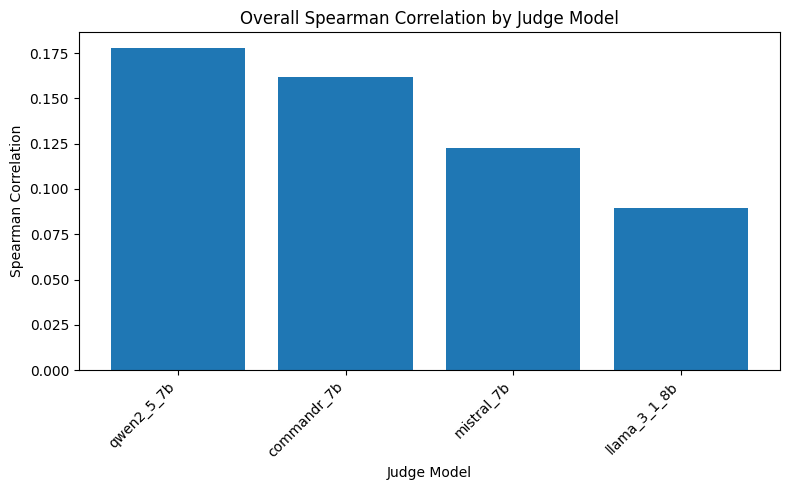

In [35]:
df_plot = df_overall.sort_values("pearson", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["judge_model"], df_plot["pearson"])

plt.title("Overall Pearson Correlation by Judge Model")
plt.xlabel("Judge Model")
plt.ylabel("Pearson Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

#plt.savefig(plots_dir / "overall_pearson_by_judge.png", dpi=300)
plt.show()


df_plot = df_overall.sort_values("spearman", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["judge_model"], df_plot["spearman"])

plt.title("Overall Spearman Correlation by Judge Model")
plt.xlabel("Judge Model")
plt.ylabel("Spearman Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

#plt.savefig(plots_dir / "overall_spearman_by_judge.png", dpi=300)
plt.show()

**Overall Pearson plot**
Qwen2.5-7B > CommandR7B > Llama-3.1-8B > Mistral-7B

**Overall Spearman plot**
Qwen2.5-7B > CommandR7B > Mistral-7B > Llama-3.1-8B

Qwen2.5-7B appears to be the strongest judge among the four selected models. However, the overall correlations are still weak, so these models should not be treated as reliable replacements for human evaluation.

Spearman is especially important here because the scores are on a 1–7 rating scale. A higher Spearman correlation means that the judge ranks responses more similarly to human raters.


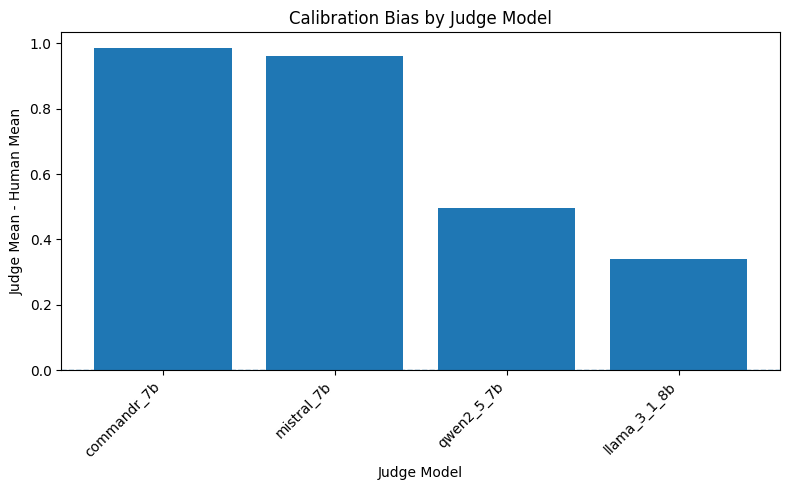

In [36]:
# Calibration bias by model
df_plot = df_overall.sort_values("judge_minus_human", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["judge_model"], df_plot["judge_minus_human"])

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Calibration Bias by Judge Model")
plt.xlabel("Judge Model")
plt.ylabel("Judge Mean - Human Mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

#plt.savefig(plots_dir / "calibration_bias_by_judge.png", dpi=300)
plt.show()

* All four judge models have a positive calibration bias.
* This means they generally give higher scores than human raters.
* CommandR7B and Mistral-7B show the strongest over-scoring bias.
* Qwen2.5-7B also over-scores, but less strongly.
* Llama-3.1-8B is closest to the human mean.


**better calibration does not necessarily mean better correlation!**

This means we should report both:

* correlation, to measure judge-human agreement;
* calibration bias, to measure whether the judge is too strict or too lenient.

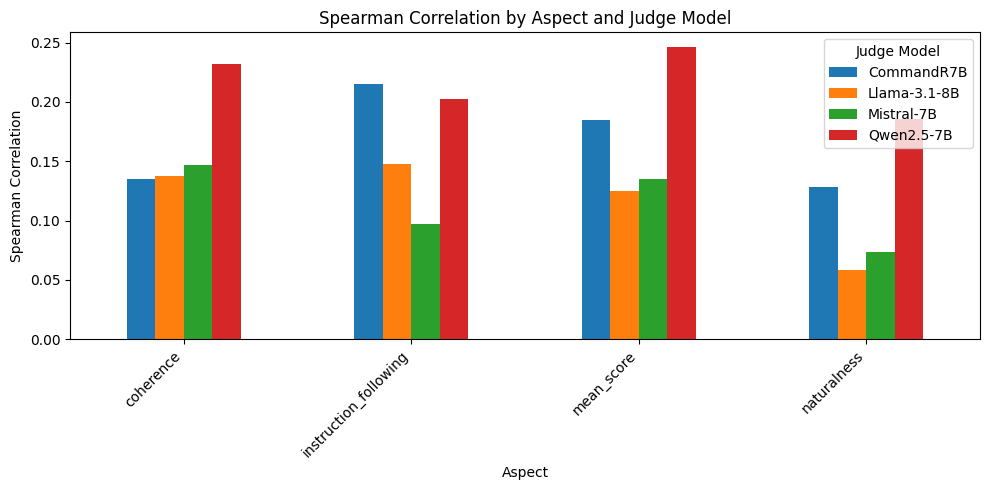

In [37]:
import matplotlib.pyplot as plt

pivot_aspect = df_by_aspect.pivot(
    index="aspect",
    columns="judge_model",
    values="spearman"
)

ax = pivot_aspect.plot(kind="bar", figsize=(10, 5))

plt.title("Spearman Correlation by Aspect and Judge Model")
plt.xlabel("Aspect")
plt.ylabel("Spearman Correlation")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Judge Model")
plt.tight_layout()
plt.show()

* Qwen2.5-7B performs best on several aspects
* CommandR7B performs particularly well on instruction following.
* Naturalness appears to be the most difficult aspect for most judges.
* Mistral-7B and Llama-3.1-8B are generally weaker or less stable across aspects.


Judge performance depends strongly on the evaluation criterion. Naturalness is especially difficult because it requires sensitivity to language-specific fluency, native-like wording, style, and cultural appropriateness.

Instruction following may be easier to judge because it is more directly connected to whether the response satisfies the prompt. Naturalness, by contrast, requires deeper knowledge of the target language.

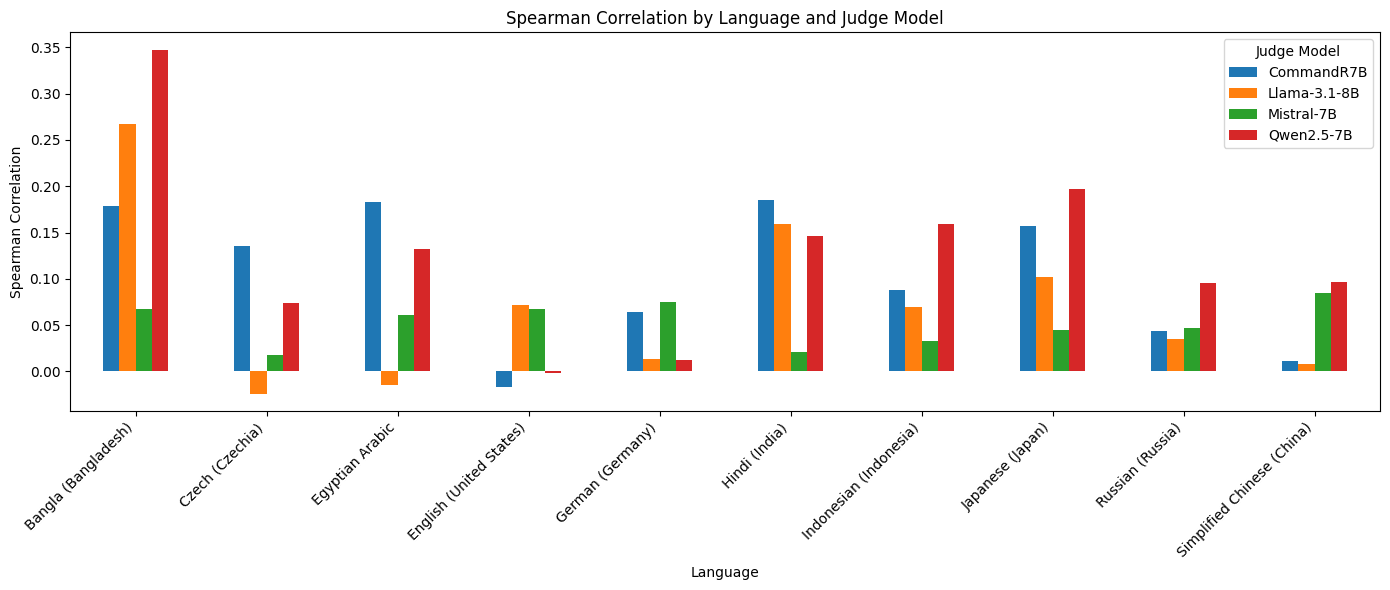

In [38]:
pivot_language = df_by_language.pivot(
    index="language_locale",
    columns="judge_model",
    values="spearman"
)

ax = pivot_language.plot(kind="bar", figsize=(14, 6))

plt.title("Spearman Correlation by Language and Judge Model")
plt.xlabel("Language")
plt.ylabel("Spearman Correlation")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Judge Model")
plt.tight_layout()
plt.show()

* Bangla shows the highest correlations, especially for Qwen2.5-7B.
* Hindi and Japanese also show relatively stronger results for some judges.
* English has near-zero or slightly negative correlation for some models.
* Czech and Egyptian Arabic also show weak or unstable correlations for several judges.
* The ranking of judge models changes depending on the language

There is clear evidence of language-level instability. The same judge model can perform reasonably well for one language but poorly for another.

This suggests that overall correlation is not enough for multilingual evaluation. A judge model may look acceptable overall, but still fail or become unreliable for specific languages.

Possible reasons include:

* different amounts of pretraining data for different languages;

* lower model sensitivity to dialects or regional language varieties;

* difficulty detecting local naturalness issues.

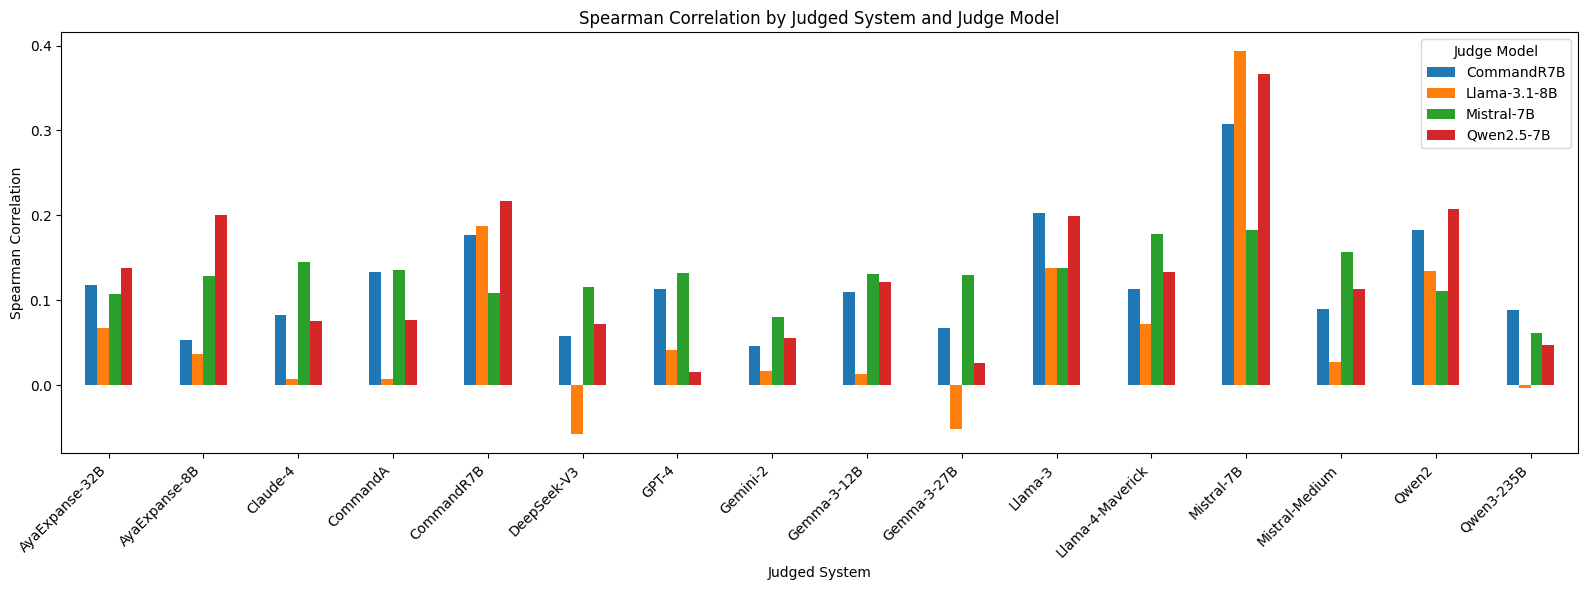

In [39]:
pivot_system = df_by_system.pivot(
    index="judged_system",
    columns="judge_model",
    values="spearman"
)

ax = pivot_system.plot(kind="bar", figsize=(16, 6))

plt.title("Spearman Correlation by Judged System and Judge Model")
plt.xlabel("Judged System")
plt.ylabel("Spearman Correlation")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Judge Model")
plt.tight_layout()
plt.show()

The judged-system plot analyzes whether judge-human agreement depends on the system whose output is being evaluated.


* Some judged systems show much higher correlations than others.
* Responses from Mistral-7B seem to produce relatively high judge-human agreement across several judges.
* Some systems show weak or even negative correlations for specific judge models.
* The same judge does not perform equally well across all judged systems.




### Motivation for Pairwise Accuracy and Acc_eq

Pearson, Spearman, and Kendall correlations are common metrics for comparing human and judge scores, but they are not fully suitable as the main metrics in this task. Pearson measures whether human scores and judge scores have a linear relationship, so it is more appropriate when we care about exact score calibration. However, in our setting, the main goal is not necessarily to reproduce the exact numerical human score, but to identify which system output is better.

Spearman and Kendall are more ranking-oriented. Spearman compares the rank order of systems, while Kendall evaluates agreement through pairwise ordering. These metrics are closer to our goal than Pearson, but they still have limitations because the dataset uses a discrete 1–7 rating scale. This creates many tied scores among systems. Standard rank correlations do not explicitly distinguish between different tie-related cases, such as when the judge breaks a human tie or assigns a tie when humans show a clear preference.

Therefore, system-level pairwise metrics are more appropriate. Pairwise accuracy directly asks whether the judge agrees with human preferences between two systems on the same item. If humans rate system A higher than system B, the judge should also rate A higher than B. This directly reflects the goal of system ranking.

However, pairwise accuracy mainly focuses on non-tied human preferences. Since ties are frequent and meaningful in this dataset, we also use acc_eq. Acc_eq treats equality as a valid relation and rewards the judge when both humans and the judge consider two systems tied. Thus, pairwise accuracy measures agreement on clear preferences, while acc_eq additionally evaluates whether the judge handles ties correctly.


##Week 3: suitable metrics


In [40]:
all_merged = pd.concat(
    [
        df_mistral_merged,
        df_qwen_merged,
        df_commandr_merged,
        df_llama_merged,
        df_ayaexpanse_32b_merged,
        df_ayaexpanse_8b_merged,
        df_claude_4_merged,
        df_commanda_merged,
        df_deepseek_v3_merged,
        df_gpt_4_1_merged,
        df_llama_4_maverick_merged,
        df_mistral_medium_merged,
        df_qwen_3_235b_merged,
    ],
    ignore_index=True
)

print(all_merged.shape)
all_merged[[
    "judge_model",
    "doc_id",
    "segment_id",
    "system",
    "language_locale",
    "aspect",
    "human_score",
    "judge_score"
]].head()

(381853, 11)


,judge_model,doc_id,segment_id,system,language_locale,aspect,human_score,judge_score
0,mistral_7b,34ff7b0c7d176187b5f56965bc072870,0,Gemma-3-27B,English (United States),instruction_following,7.0,7.0
1,mistral_7b,34ff7b0c7d176187b5f56965bc072870,0,Gemma-3-27B,English (United States),coherence,7.0,7.0
2,mistral_7b,34ff7b0c7d176187b5f56965bc072870,0,Gemma-3-27B,English (United States),naturalness,7.0,7.0
3,mistral_7b,25206396b6f90a56a632de9594cfa279,1,Gemma-3-27B,English (United States),instruction_following,5.0,6.0
4,mistral_7b,25206396b6f90a56a632de9594cfa279,1,Gemma-3-27B,English (United States),coherence,5.0,6.0


main metrics are used:
- System-level: Pairwise Accuracy
- Segment/item-level: group-by-item acceq


Overall, pairwise accuracy measures how well the judge captures clear human preferences between systems, while group-by-item acc_eq additionally evaluates whether the judge handles tied ratings correctly. Together, these two metrics provide a more appropriate evaluation of LLM judges than standard correlation metrics in a dataset with many discrete and tied human ratings.

In [41]:
from itertools import combinations
import numpy as np
import pandas as pd

In [42]:
def get_relation(score_a, score_b, tie_threshold=0.0):
    """
    Return relation between two scores:
    1  = A > B
    -1 = A < B
    0  = tie
    """
    diff = score_a - score_b

    if abs(diff) <= tie_threshold:
        return 0
    elif diff > 0:
        return 1
    else:
        return -1

In [43]:
def compute_system_pairwise_accuracy(
    df,
    group_cols,
    system_col="system",
    human_col="human_score",
    judge_col="judge_score",
    tie_threshold=0.0,
):
    rows = []

    for group_key, group in df.groupby(group_cols):
        scores = (
            group
            .groupby(system_col)
            .agg(
                human_mean=(human_col, "mean"),
                judge_mean=(judge_col, "mean")
            )
            .reset_index()
        )

        correct = 0
        total = 0
        human_ties_ignored = 0

        for a, b in combinations(scores.index, 2):
            h_rel = get_relation(
                scores.loc[a, "human_mean"],
                scores.loc[b, "human_mean"],
                tie_threshold=tie_threshold
            )

            j_rel = get_relation(
                scores.loc[a, "judge_mean"],
                scores.loc[b, "judge_mean"],
                tie_threshold=tie_threshold
            )

            # system-level pairwise accuracy ignores human ties
            if h_rel == 0:
                human_ties_ignored += 1
                continue

            if h_rel == j_rel:
                correct += 1

            total += 1

        pairwise_accuracy = correct / total if total > 0 else np.nan

        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        row = dict(zip(group_cols, group_key))
        row.update({
            "pairwise_accuracy": pairwise_accuracy,
            "correct_pairs": correct,
            "n_pairs": total,
            "human_ties_ignored": human_ties_ignored,
        })

        rows.append(row)

    return pd.DataFrame(rows)

In [44]:
df_pairwise_overall = compute_system_pairwise_accuracy(
    all_merged,
    group_cols=["judge_model"]
)

df_pairwise_overall.sort_values("pairwise_accuracy", ascending=False)

,judge_model,pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored
2,claude_4,0.941667,113,120,0
6,gpt_4_1,0.925000,111,120,0
3,commanda,0.916667,110,120,0
12,qwen_3_235b,0.908333,109,120,0
10,mistral_medium,0.883333,106,120,0
5,deepseek_v3,0.858333,103,120,0
8,llama_4_maverick,0.841667,101,120,0
0,ayaexpanse_32b,0.741667,89,120,0
11,qwen2_5_7b,0.708333,85,120,0
7,llama_3_1_8b,0.641667,77,120,0


In [45]:
df_pairwise_by_aspect = compute_system_pairwise_accuracy(
    all_merged,
    group_cols=["judge_model", "aspect"]
)

df_pairwise_by_aspect.sort_values(
    ["aspect", "pairwise_accuracy"],
    ascending=[True, False]
)

,judge_model,aspect,pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored
8,claude_4,coherence,0.950000,114,120,0
12,commanda,coherence,0.933333,112,120,0
24,gpt_4_1,coherence,0.933333,112,120,0
48,qwen_3_235b,coherence,0.908333,109,120,0
40,mistral_medium,coherence,0.900000,108,120,0
20,deepseek_v3,coherence,0.841667,101,120,0
32,llama_4_maverick,coherence,0.783333,94,120,0
44,qwen2_5_7b,coherence,0.716667,86,120,0
0,ayaexpanse_32b,coherence,0.683333,82,120,0
16,commandr_7b,coherence,0.625000,75,120,0


In [46]:
df_pairwise_by_language = compute_system_pairwise_accuracy(
    all_merged,
    group_cols=["judge_model", "language_locale"]
)

df_pairwise_by_language.sort_values(
    ["language_locale", "pairwise_accuracy"],
    ascending=[True, False]
)

,judge_model,language_locale,pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored
100,mistral_medium,Bangla (Bangladesh),0.941176,112,119,1
50,deepseek_v3,Bangla (Bangladesh),0.915966,109,119,1
80,llama_4_maverick,Bangla (Bangladesh),0.915966,109,119,1
20,claude_4,Bangla (Bangladesh),0.899160,107,119,1
60,gpt_4_1,Bangla (Bangladesh),0.865546,103,119,1
...,...,...,...,...,...,...
19,ayaexpanse_8b,Simplified Chinese (China),0.655462,78,119,1
89,llama_4_maverick,Simplified Chinese (China),0.647059,77,119,1
49,commandr_7b,Simplified Chinese (China),0.554622,66,119,1
79,llama_3_1_8b,Simplified Chinese (China),0.504202,60,119,1


In [47]:
def compute_acceq_by_item(
    df,
    item_cols,
    system_col="system",
    human_col="human_score",
    judge_col="judge_score",
    human_tie_threshold=0.0,
    judge_tie_threshold=0.0,
):
    rows = []

    for item_key, group in df.groupby(item_cols):
        scores = (
            group
            .groupby(system_col)
            .agg(
                human_score=(human_col, "mean"),
                judge_score=(judge_col, "mean")
            )
            .reset_index()
        )

        C = 0
        D = 0
        T_h = 0
        T_m = 0
        T_hm = 0

        for a, b in combinations(scores.index, 2):
            h_rel = get_relation(
                scores.loc[a, "human_score"],
                scores.loc[b, "human_score"],
                tie_threshold=human_tie_threshold
            )

            j_rel = get_relation(
                scores.loc[a, "judge_score"],
                scores.loc[b, "judge_score"],
                tie_threshold=judge_tie_threshold
            )

            if h_rel == 0 and j_rel == 0:
                T_hm += 1
            elif h_rel == 0 and j_rel != 0:
                T_h += 1
            elif h_rel != 0 and j_rel == 0:
                T_m += 1
            elif h_rel == j_rel:
                C += 1
            else:
                D += 1

        total = C + D + T_h + T_m + T_hm
        acceq = (C + T_hm) / total if total > 0 else np.nan

        if not isinstance(item_key, tuple):
            item_key = (item_key,)

        row = dict(zip(item_cols, item_key))
        row.update({
            "acceq": acceq,
            "C": C,
            "D": D,
            "T_h": T_h,
            "T_m": T_m,
            "T_hm": T_hm,
            "n_pairs": total,
        })

        rows.append(row)

    return pd.DataFrame(rows)

In [48]:
item_cols = [
    "judge_model",
    "doc_id",
    "segment_id",
    "language_locale",
    "aspect"
]
df_acceq_items = compute_acceq_by_item(
    all_merged,
    item_cols=item_cols,
    human_tie_threshold=0.0,
    judge_tie_threshold=0.0
)

df_acceq_items.head()

,judge_model,doc_id,segment_id,language_locale,aspect,acceq,C,D,T_h,T_m,T_hm,n_pairs
0,ayaexpanse_32b,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),coherence,0.225,0,0,0,93,27,120
1,ayaexpanse_32b,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),instruction_following,1.000,0,0,0,0,120,120
2,ayaexpanse_32b,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),mean_score,0.275,11,2,2,83,22,120
3,ayaexpanse_32b,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),naturalness,0.575,11,1,3,47,58,120
4,ayaexpanse_32b,0a3da1ceeb83f664b813bb28f001d766,1370,Japanese (Japan),coherence,0.650,12,3,13,26,66,120


In [49]:
df_acceq_overall = (
    df_acceq_items
    .groupby("judge_model", as_index=False)
    .agg(
        acceq=("acceq", "mean"),
        n_items=("acceq", "size"),
        avg_pairs=("n_pairs", "mean"),
        total_C=("C", "sum"),
        total_D=("D", "sum"),
        total_T_h=("T_h", "sum"),
        total_T_m=("T_m", "sum"),
        total_T_hm=("T_hm", "sum"),
    )
    .sort_values("acceq", ascending=False)
)

df_acceq_overall

,judge_model,acceq,n_items,avg_pairs,total_C,total_D,total_T_h,total_T_m,total_T_hm
2,claude_4,0.549191,1836,119.983660,56290,13774,33287,52245,64694
6,gpt_4_1,0.545438,1836,120.000000,37271,6428,15102,78619,82900
12,qwen_3_235b,0.544985,1836,120.000000,36750,6508,14681,79060,83321
3,commanda,0.541989,1836,120.000000,36432,6361,15023,79525,82979
10,mistral_medium,0.533588,1836,120.000000,45466,10752,25908,66100,72094
5,deepseek_v3,0.518419,1836,120.000000,36542,10303,20326,75473,77676
8,llama_4_maverick,0.504879,1836,120.000000,36567,11016,23334,74735,74668
0,ayaexpanse_32b,0.483370,1836,120.000000,40232,17677,31738,64409,66264
11,qwen2_5_7b,0.462722,1836,120.000000,37399,18477,33454,66442,64548
4,commandr_7b,0.459818,1836,120.000000,21042,11029,17737,90247,80265


In [50]:
df_acceq_by_aspect = (
    df_acceq_items
    .groupby(["judge_model", "aspect"], as_index=False)
    .agg(
        acceq=("acceq", "mean"),
        n_items=("acceq", "size"),
        avg_pairs=("n_pairs", "mean"),
        total_C=("C", "sum"),
        total_D=("D", "sum"),
        total_T_h=("T_h", "sum"),
        total_T_m=("T_m", "sum"),
        total_T_hm=("T_hm", "sum"),
    )
    .sort_values(["aspect", "acceq"], ascending=[True, False])
)

df_acceq_by_aspect

,judge_model,aspect,acceq,n_items,avg_pairs,total_C,total_D,total_T_h,total_T_m,total_T_hm
24,gpt_4_1,coherence,0.591649,459,120.000000,7891,1205,3847,17440,24697
48,qwen_3_235b,coherence,0.590632,459,120.000000,8436,1487,4448,16613,24096
12,commanda,coherence,0.590251,459,120.000000,7934,1305,3967,17297,24577
8,claude_4,coherence,0.562418,459,120.000000,11483,2651,9049,12402,19495
40,mistral_medium,coherence,0.557480,459,120.000000,9842,2252,7680,14442,20864
32,llama_4_maverick,coherence,0.556373,459,120.000000,7604,1688,5503,17244,23041
20,deepseek_v3,coherence,0.532262,459,120.000000,9198,2704,8425,14634,20119
16,commandr_7b,coherence,0.513689,459,120.000000,3962,1785,4212,20789,24332
0,ayaexpanse_32b,coherence,0.506373,459,120.000000,7971,3394,8624,15171,19920
44,qwen2_5_7b,coherence,0.479775,459,120.000000,6670,3258,8788,16608,19756


In [51]:
df_acceq_by_language = (
    df_acceq_items
    .groupby(["judge_model", "language_locale"], as_index=False)
    .agg(
        acceq=("acceq", "mean"),
        n_items=("acceq", "size"),
        avg_pairs=("n_pairs", "mean"),
        total_C=("C", "sum"),
        total_D=("D", "sum"),
        total_T_h=("T_h", "sum"),
        total_T_m=("T_m", "sum"),
        total_T_hm=("T_hm", "sum"),
    )
    .sort_values(["language_locale", "acceq"], ascending=[True, False])
)

df_acceq_by_language

,judge_model,language_locale,acceq,n_items,avg_pairs,total_C,total_D,total_T_h,total_T_m,total_T_hm
20,claude_4,Bangla (Bangladesh),0.523868,184,120.0,9248,2575,3755,4183,2319
100,mistral_medium,Bangla (Bangladesh),0.504846,184,120.0,8376,2306,3303,5324,2771
120,qwen_3_235b,Bangla (Bangladesh),0.498098,184,120.0,7542,1721,2618,6743,3456
60,gpt_4_1,Bangla (Bangladesh),0.496649,184,120.0,7513,1670,2621,6823,3453
50,deepseek_v3,Bangla (Bangladesh),0.493705,184,120.0,7624,1873,2797,6509,3277
...,...,...,...,...,...,...,...,...,...,...
89,llama_4_maverick,Simplified Chinese (China),0.540353,184,120.0,1876,1066,2911,6172,10055
119,qwen2_5_7b,Simplified Chinese (China),0.539991,184,120.0,2369,1343,3412,5402,9554
9,ayaexpanse_32b,Simplified Chinese (China),0.512047,184,120.0,2782,1606,4442,4726,8524
99,mistral_7b,Simplified Chinese (China),0.480616,184,120.0,1715,1585,4069,5814,8897


In [52]:
df_metric_compare = (
    df_overall
    .merge(
        df_pairwise_overall[["judge_model", "pairwise_accuracy"]],
        on="judge_model",
        how="left"
    )
    .merge(
        df_acceq_overall[["judge_model", "acceq"]],
        on="judge_model",
        how="left"
    )
)

df_metric_compare.sort_values("acceq", ascending=False)

,judge_model,n,spearman,pearson,human_mean,judge_mean,judge_minus_human,pairwise_accuracy,acceq
0,qwen2_5_7b,29376,0.177562,0.239224,5.67352,6.170615,0.497095,0.708333,0.462722
1,commandr_7b,29376,0.161995,0.223444,5.67352,6.658224,0.984704,0.625000,0.459818
2,mistral_7b,29376,0.122386,0.146365,5.67352,6.634622,0.961102,0.558333,0.422072
3,llama_3_1_8b,29376,0.089752,0.186079,5.67352,6.014570,0.341049,0.641667,0.422013


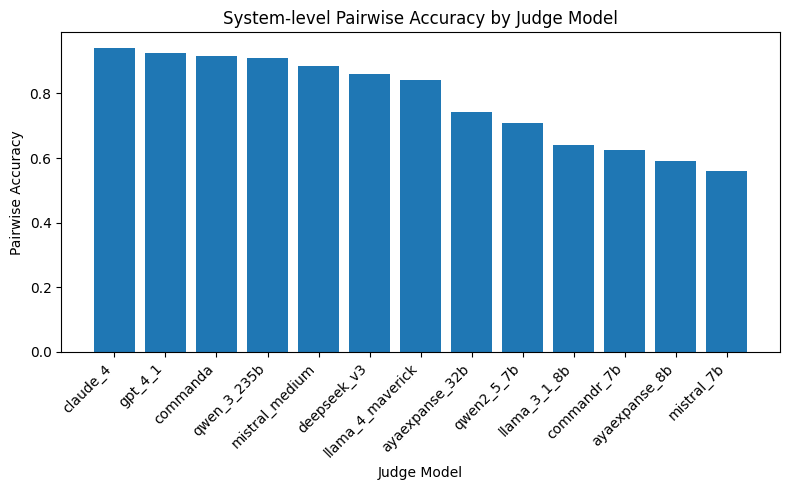

In [53]:
#overall pairwise accuracy
import matplotlib.pyplot as plt

df_plot = df_pairwise_overall.sort_values("pairwise_accuracy", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["judge_model"], df_plot["pairwise_accuracy"])
plt.title("System-level Pairwise Accuracy by Judge Model")
plt.xlabel("Judge Model")
plt.ylabel("Pairwise Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

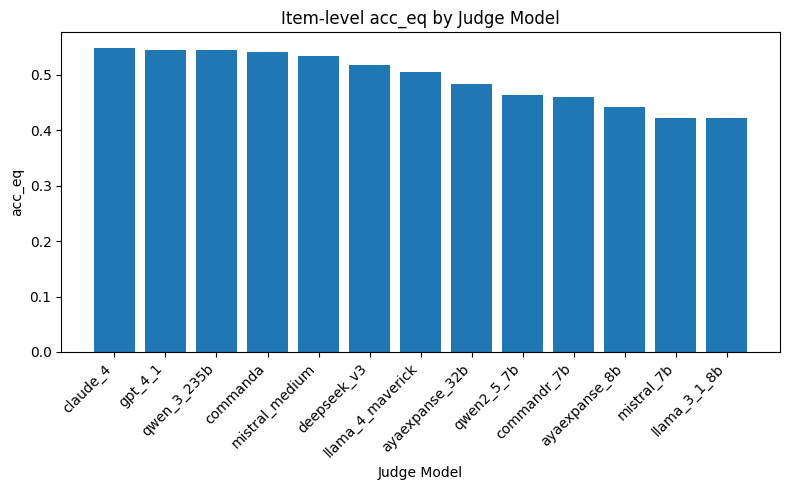

In [54]:
df_plot = df_acceq_overall.sort_values("acceq", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["judge_model"], df_plot["acceq"])
plt.title("Item-level acc_eq by Judge Model")
plt.xlabel("Judge Model")
plt.ylabel("acc_eq")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Pairwise Accuracy and acc_eq

The previous analysis used Pearson and Spearman correlations between human and judge scores. However, the findings paper also uses pairwise ranking-based metrics. Therefore, we add system-level Pairwise Accuracy and item-level acc_eq.

System-level Pairwise Accuracy checks whether the judge ranks systems in the same order as human ratings after aggregating scores by system.

Item-level acc_eq compares all pairs of system outputs within the same item and gives credit both for correct orderings and correctly predicted ties.

**Week 4: Load lightweight model**

Test lightweight instruction-tuned models such as Qwen2.5-1.5B-Instruct, Qwen2.5-3B-Instruct, and Gemma-2-2B-IT.

Try a more multilingual-focused model such as Aya-Expanse-8B.

In [55]:
!pip install -q transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.5 MB/s eta 0:00:00


In [56]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [57]:
hf_sample = (
    df_human_long[
        (df_human_long["language_locale"] == "English (United States)") &
        (df_human_long["aspect"].isin([
            "coherence",
            "naturalness",
            "instruction_following"
        ]))
    ]
    .groupby("human_score", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 2), random_state=42))
    .reset_index(drop=True)
)

print(hf_sample.shape)
hf_sample["human_score"].value_counts().sort_index()

(12, 9)


/tmp/ipykernel_4424/2475734770.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 2), random_state=42))


,count
human_score,
2.0,2
3.0,2
4.0,2
5.0,2
6.0,2
7.0,2


In [58]:
judge_model_1 = "Qwen/Qwen2.5-1.5B-Instruct"
judge_model_2 = "Qwen/Qwen2.5-3B-Instruct"
judge_model_3 = "mistralai/Mistral-7B-Instruct-v0.3"

In [59]:
#Load model
tokenizer = AutoTokenizer.from_pretrained(judge_model_2)

model = AutoModelForCausalLM.from_pretrained(
    judge_model_2,
    device_map="auto",
    torch_dtype=torch.float16
)

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-35): 36 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (k_proj): Linear(in_features=2048, out_features=256, bias=True)
          (v_proj): Linear(in_features=2048, out_features=256, bias=True)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (up_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((2048,), eps=1e-06)
    (ro

In [60]:
def direct_prompt(row):
    return f"""You are a strict evaluator.

Your task is to evaluate the response according to the given aspect.

Aspect:
{row["aspect"]}

Use a score from 1 to 7:
1 = very poor
2 = poor
3 = weak
4 = acceptable
5 = good
6 = very good
7 = excellent

Return only one integer from 1 to 7. Do not explain.

User prompt:
{row["prompt"]}

Response:
{row["response"]}

Score:"""

In [61]:
def generate_judge_output(prompt, max_new_tokens=150):
    messages = [
        {"role": "user", "content": prompt}
    ]

    if hasattr(tokenizer, "apply_chat_template"):
        input_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
    else:
        input_text = prompt

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=4096
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    output_text = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    return output_text.strip()

In [62]:
def parse_score(text):
    """
    Extract first integer score from 1 to 7.
    """
    match = re.search(r"\b([1-7])\b", str(text))
    if match:
        return int(match.group(1))
    return np.nan

In [63]:
hf_outputs = []

for count, (idx, row) in enumerate(hf_sample.iterrows(), start=1):
    prompt = direct_prompt(row)
    output = generate_judge_output(prompt)
    score = parse_score(output)

    hf_outputs.append({
        "index": idx,
        "hf_raw_output": output,
        "judge_score": score,
    })

    if count % 10 == 0:
        print(f"Processed {count}/{len(hf_sample)}")

KeyboardInterrupt: 

In [64]:
df_hf_outputs = pd.DataFrame(hf_outputs)

df_hf_outputs.head()

,index,hf_raw_output,judge_score
0,0,4,4


In [65]:
df_hf_judge = hf_sample.reset_index().merge(
    df_hf_outputs,
    on="index",
    how="left"
)

df_hf_judge["judge_model"] = judge_model_2

df_hf_judge[
    ["language_locale", "system", "aspect", "human_score", "judge_score"]
].head()

,language_locale,system,aspect,human_score,judge_score
0,English (United States),Mistral-7B,coherence,2.0,4.0
1,English (United States),Llama-3,coherence,2.0,NaN
2,English (United States),Gemini-2,instruction_following,3.0,NaN
3,English (United States),Gemma-3-12B,instruction_following,3.0,NaN
4,English (United States),AyaExpanse-8B,instruction_following,4.0,NaN


##Week 5: try some different types of prompt

- direct scoring prompt is the baseline
- aspect-specific / rubric-based prompts
- rational + final score prompt
- scoring with uncertainty intervals

In [66]:
def aspect_specific_prompt(row):
    aspect = row["aspect"]
    language = row.get("language_locale", "the target language")

    if aspect == "coherence":
        aspect_instruction = """
Evaluate ONLY coherence.

Focus on:
- logical consistency
- clear structure
- whether ideas connect well
- whether the response is easy to follow
- contradictions or confusing parts

Do NOT penalize mainly for:
- unnatural wording, unless it makes the response hard to understand
- small instruction-following issues, unless they make the response incoherent
"""
    elif aspect == "naturalness":
        aspect_instruction = f"""
Evaluate ONLY naturalness.

The target language is: {language}

Focus on:
- fluency in {language}
- idiomatic and native-like wording
- natural sentence structure
- whether the response sounds like something a fluent speaker would write
- awkward, translated, or unnatural phrasing

Do NOT penalize mainly for:
- missing content, unless it makes the language unnatural
- instruction-following issues, unless they directly affect naturalness
"""
    elif aspect == "instruction_following":
        aspect_instruction = """
Evaluate ONLY instruction following.

Focus on:
- whether the response answers the user's request
- whether it follows all explicit constraints
- whether it uses the requested format, style, language, length, or content
- whether important parts of the instruction are missing

Do NOT penalize mainly for:
- unnatural wording, unless it prevents task completion
- minor coherence issues, unless they make the response fail the instruction
"""
    else:
        aspect_instruction = f"""
Evaluate ONLY this aspect:
{aspect}
"""

    return f"""You are a strict evaluator for multilingual open-ended generation.

{aspect_instruction}

Use a score from 1 to 7:
1 = very poor
2 = poor
3 = weak
4 = acceptable
5 = good
6 = very good
7 = excellent

Return only one integer from 1 to 7. Do not explain.

User prompt:
{row["prompt"]}

Response:
{row["response"]}

Score:"""

In [67]:
outputs = []

for i, row in hf_sample.iterrows():
    prompt = aspect_specific_prompt(row)
    raw_output = generate_judge_output(prompt)
    score = parse_score(raw_output)

    outputs.append({
        "aspect": row["aspect"],
        "language_locale": row["language_locale"],
        "human_score": row["human_score"],
        "hf_raw_output": raw_output,
        "judge_score": score
    })

    print(
        f"[{len(outputs)}/{len(hf_sample)}] "
        f"{row['language_locale']} | "
        f"{row['aspect']} | "
        f"human={row['human_score']} | "
        f"judge={score} | "
        f"raw={raw_output}"
    )

df_aspect_specific_prompt = pd.DataFrame(outputs)

KeyboardInterrupt: 

In [ ]:
df_hf_judge["judge_score"].value_counts(dropna=False).sort_index()
df_aspect_specific_prompt["judge_score"].value_counts(dropna=False).sort_index()

In [68]:
def rationale_final_score_prompt(row):
    aspect = row["aspect"]
    language = row.get("language_locale", "the target language")

    if aspect == "coherence":
        criterion = """
Evaluate ONLY coherence.

Coherence means:
- logical consistency;
- clear structure;
- ideas connect well;
- the response is easy to follow;
- no contradictions or confusing jumps.

Do not mainly judge naturalness or instruction following unless they directly affect coherence.
"""

    elif aspect == "naturalness":
        criterion = f"""
Evaluate ONLY naturalness.

The target language is: {language}

Naturalness means:
- fluency in {language};
- idiomatic and native-like wording;
- natural sentence structure;
- the response does not sound awkward or translated.

Do not mainly judge content completeness or instruction following unless they directly affect naturalness.
"""

    elif aspect == "instruction_following":
        criterion = """
Evaluate ONLY instruction following.

Instruction following means:
- the response answers the user's request;
- it follows explicit constraints;
- it uses the requested format, style, language, length, or content;
- it does not ignore important parts of the prompt.

Do not mainly judge naturalness or coherence unless they prevent task completion.
"""

    else:
        criterion = f"""
Evaluate ONLY this aspect:
{aspect}
"""

    return f"""You are a strict evaluator for multilingual open-ended generation.

{criterion}

Use a score from 1 to 7:
1 = very poor
2 = poor
3 = weak
4 = acceptable
5 = good
6 = very good
7 = excellent

Instructions:
- First write ONE short sentence explaining the main reason for your score.
- Then give the final score.
- Judge only the current aspect.
- Do not give 7 unless the response is excellent for this aspect.

Return exactly this format:
Rationale: <one short sentence>
Final score: <one integer from 1 to 7>

User prompt:
{row["prompt"]}

Response:
{row["response"]}"""

In [ ]:
outputs = []

for i, row in hf_sample.iterrows():
    prompt = rationale_final_score_prompt(row)
    raw_output = generate_judge_output(prompt)
    score = parse_score(raw_output)

    outputs.append({
        "aspect": row["aspect"],
        "language_locale": row["language_locale"],
        "human_score": row["human_score"],
        "hf_raw_output": raw_output,
        "judge_score": score
    })

    print(
        f"[{len(outputs)}/{len(hf_sample)}] "
        f"{row['language_locale']} | "
        f"{row['aspect']} | "
        f"human={row['human_score']} | "
        f"judge={score} | "
        f"raw={raw_output}"
    )

df_rationale_prompt = pd.DataFrame(outputs)

In [69]:
metadata_cols = [
    "doc_id",
    "segment_id",
    "system",
    "language",
    "language_locale",
    "aspect",
    "human_score",
    "prompt",
    "response",
]

metadata_cols = [col for col in metadata_cols if col in hf_sample.columns]

def add_metadata_by_order(df_result, hf_sample, metadata_cols):
    df_fixed = df_result.reset_index(drop=True).copy()
    meta = hf_sample[metadata_cols].reset_index(drop=True).copy()

    for col in metadata_cols:
        if col not in df_fixed.columns:
            df_fixed[col] = meta[col]
        else:
            df_fixed[col] = df_fixed[col].fillna(meta[col])

    return df_fixed

In [70]:
df_hf_judge = add_metadata_by_order(
    df_hf_judge,
    hf_sample,
    metadata_cols
)

df_aspect_specific_prompt = add_metadata_by_order(
    df_aspect_specific_prompt,
    hf_sample,
    metadata_cols
)

df_rationale_prompt = add_metadata_by_order(
    df_rationale_prompt,
    hf_sample,
    metadata_cols
)

NameError: name 'df_aspect_specific_prompt' is not defined

In [71]:
print("direct systems:", df_hf_judge["system"].nunique())
print("aspect_rubric systems:", df_aspect_specific_prompt["system"].nunique())
print("rationale systems:", df_rationale_prompt["system"].nunique())

direct systems: 10


NameError: name 'df_aspect_specific_prompt' is not defined

In [72]:
prompt_result_dfs = {
    "direct": df_hf_judge,
    "aspect_rubric": df_aspect_specific_prompt,
    "rationale_final": df_rationale_prompt,
}

all_results = []

for prompt_name, df in prompt_result_dfs.items():
    temp = df.copy()
    temp["prompt_variant"] = prompt_name
    all_results.append(temp)

df_prompt_all = pd.concat(all_results, ignore_index=True)

df_prompt_all["human_score"] = pd.to_numeric(
    df_prompt_all["human_score"],
    errors="coerce"
)

df_prompt_all["judge_score"] = pd.to_numeric(
    df_prompt_all["judge_score"],
    errors="coerce"
)

df_prompt_all.head()

NameError: name 'df_aspect_specific_prompt' is not defined

In [73]:
score_dist = (
    df_prompt_all
    .groupby(["prompt_variant", "judge_score"])
    .size()
    .reset_index(name="count")
)

score_dist

NameError: name 'df_prompt_all' is not defined

In [ ]:
score_dist_pivot = score_dist.pivot(
    index="prompt_variant",
    columns="judge_score",
    values="count"
).fillna(0)

score_dist_pivot

In [ ]:
prompt_metric_rows = []

for prompt_name, group in df_prompt_all.groupby("prompt_variant"):
    clean = group[["human_score", "judge_score"]].dropna()

    error = clean["judge_score"] - clean["human_score"]

    result = {
        "prompt_variant": prompt_name,
        "n": len(clean),
        "invalid_rate": 1 - len(clean) / len(group),
        "human_mean": clean["human_score"].mean(),
        "judge_mean": clean["judge_score"].mean(),
        "bias": clean["judge_score"].mean() - clean["human_score"].mean(),
        "mae": error.abs().mean(),
        "rmse": np.sqrt((error ** 2).mean()),
        "judge_std": clean["judge_score"].std(),
        "pearson": np.nan,
        "spearman": np.nan,
    }

    if (
        len(clean) >= 3
        and clean["human_score"].nunique() > 1
        and clean["judge_score"].nunique() > 1
    ):
        result["pearson"] = pearsonr(
            clean["human_score"],
            clean["judge_score"]
        )[0]

        result["spearman"] = spearmanr(
            clean["human_score"],
            clean["judge_score"]
        )[0]

    prompt_metric_rows.append(result)

df_prompt_metrics = pd.DataFrame(prompt_metric_rows)

df_prompt_metrics.sort_values("mae")

In [ ]:
df_plot = df_prompt_metrics.sort_values("bias", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["prompt_variant"], df_plot["bias"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Calibration bias by prompt")
plt.xlabel("Prompt variant")
plt.ylabel("Judge mean - human mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
needed_cols = ["doc_id", "segment_id", "system", "language_locale", "aspect"]

[col for col in needed_cols if col not in df_prompt_all.columns]

In [ ]:
df_prompt_pairwise = compute_system_pairwise_accuracy(
    df_prompt_all,
    group_cols=["prompt_variant"]
)

df_prompt_pairwise.sort_values("pairwise_accuracy", ascending=False)

In [ ]:
prompt_result_dfs = {
    "direct_prompt": df_hf_judge,
    "aspect_rubric_prompt": df_aspect_specific_prompt,
    "rationale_final_prompt": df_rationale_prompt,
}

prompt_results = []

for variant_name, df in prompt_result_dfs.items():
    temp = df.copy()
    temp["source_variant"] = variant_name
    prompt_results.append(temp)

df_prompt_scores = pd.concat(prompt_results, ignore_index=True)

df_prompt_scores["human_score"] = pd.to_numeric(
    df_prompt_scores["human_score"],
    errors="coerce"
)

df_prompt_scores["judge_score"] = pd.to_numeric(
    df_prompt_scores["judge_score"],
    errors="coerce"
)

df_prompt_scores[
    ["source_variant", "doc_id", "segment_id", "system", "aspect", "human_score", "judge_score"]
].head()

In [ ]:
subset_keys = df_prompt_scores[
    [
        "doc_id",
        "segment_id",
        "system",
        "language_locale",
        "aspect",
    ]
].drop_duplicates()

df_shared_qwen_subset = df_qwen_merged.merge(
    subset_keys,
    on=[
        "doc_id",
        "segment_id",
        "system",
        "language_locale",
        "aspect",
    ],
    how="inner"
).copy()

df_shared_qwen_subset["source_variant"] = "shared_task_mistral"

df_shared_qwen_subset = df_shared_qwen_subset[
    [
        "source_variant",
        "doc_id",
        "segment_id",
        "system",
        "language_locale",
        "aspect",
        "human_score",
        "judge_score",
    ]
]

df_shared_qwen_subset.shape

In [ ]:
print("Prompt rows per variant:")
print(df_prompt_scores["source_variant"].value_counts())

print("\nShared-task Mistral subset rows:")
print(df_shared_qwen_subset.shape)

In [ ]:
df_compare_sources = pd.concat(
    [
        df_shared_qwen_subset,
        df_prompt_scores[
            [
                "source_variant",
                "doc_id",
                "segment_id",
                "system",
                "language_locale",
                "aspect",
                "human_score",
                "judge_score",
            ]
        ],
    ],
    ignore_index=True
)

df_compare_sources["human_score"] = pd.to_numeric(
    df_compare_sources["human_score"],
    errors="coerce"
)

df_compare_sources["judge_score"] = pd.to_numeric(
    df_compare_sources["judge_score"],
    errors="coerce"
)

df_compare_sources.groupby("source_variant").agg(
    rows=("judge_score", "size"),
    valid_scores=("judge_score", "count"),
    unique_systems=("system", "nunique"),
    unique_items=("doc_id", "nunique"),
    unique_scores=("judge_score", "nunique"),
)

In [ ]:
df_compare_pairwise = compute_system_pairwise_accuracy(
    df_compare_sources,
    group_cols=["source_variant"]
)

df_compare_pairwise.sort_values("pairwise_accuracy", ascending=False)

The aspect_rubric_prompt performs best, achieving a pairwise accuracy of 0.628 with 27 correct decisions out of 43 comparable system pairs. This suggests that explicit aspect-level rubrics help the judge better reproduce human system preferences. The rationale_final_prompt ranks second with 0.581, indicating that rationale-based scoring can also improve over a simple direct prompt. Both prompt-engineered variants outperform the shared_task_mistral baseline and the direct_prompt.

The direct_prompt has the lowest pairwise accuracy at 0.488, which suggests that minimal scoring instructions are not sufficient for reliable system-level comparison in this sample. However, the evaluation is based on only 43 comparable pairs, with 2 human ties ignored, so the results should be considered preliminary. A larger evaluation sample is needed to confirm the robustness of this ranking.


In [ ]:
df_compare_sources.head(15)

In [ ]:
key_cols = [
    "doc_id",
    "segment_id",
    "system",
    "language_locale",
    "aspect",
    "human_score"
]

df_compare_wide = df_compare_sources.pivot_table(
    index=key_cols,
    columns="source_variant",
    values="judge_score",
    aggfunc="first"
).reset_index()

# bỏ tên index của columns cho đẹp
df_compare_wide.columns.name = None

df_compare_wide.head(15)

##Week 6: Test on bigger sample

In [74]:
hf_sample_big = (
    df_human_long[
        (df_human_long["language_locale"] == "English (United States)") &
        (df_human_long["aspect"].isin([
            "coherence",
            "naturalness",
            "instruction_following"
        ]))
    ]
    .groupby("human_score", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 50), random_state=42))
    .reset_index(drop=True)
)

print(hf_sample_big.shape)
hf_sample_big["human_score"].value_counts().sort_index()

(222, 9)


/tmp/ipykernel_4424/3133872903.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 50), random_state=42))


,count
human_score,
2.0,7
3.0,15
4.0,50
5.0,50
6.0,50
7.0,50


In [ ]:
outputs = []

for i, row in hf_sample_big.iterrows():
    prompt = direct_prompt(row)
    raw_output = generate_judge_output(prompt)
    score = parse_score(raw_output)

    outputs.append({
        "aspect": row["aspect"],
        "language_locale": row["language_locale"],
        "human_score": row["human_score"],
        "hf_raw_output": raw_output,
        "judge_score": score
    })

    print(
        f"[{len(outputs)}/{len(hf_sample_big)}] "
        f"{row['language_locale']} | "
        f"{row['aspect']} | "
        f"human={row['human_score']} | "
        f"judge={score} | "
        f"raw={raw_output}"
    )

df_direct_prompt_big = pd.DataFrame(outputs)

In [ ]:
outputs = []

for i, row in hf_sample_big.iterrows():
    prompt = aspect_specific_prompt(row)
    raw_output = generate_judge_output(prompt)
    score = parse_score(raw_output)

    outputs.append({
        "aspect": row["aspect"],
        "language_locale": row["language_locale"],
        "human_score": row["human_score"],
        "hf_raw_output": raw_output,
        "judge_score": score
    })

    print(
        f"[{len(outputs)}/{len(hf_sample_big)}] "
        f"{row['language_locale']} | "
        f"{row['aspect']} | "
        f"human={row['human_score']} | "
        f"judge={score} | "
        f"raw={raw_output}"
    )

df_aspect_specific_prompt_big = pd.DataFrame(outputs)

In [ ]:
outputs = []

for i, row in hf_sample_big.iterrows():
    prompt = rationale_final_score_prompt(row)
    raw_output = generate_judge_output(prompt)
    score = parse_score(raw_output)

    outputs.append({
        "aspect": row["aspect"],
        "language_locale": row["language_locale"],
        "human_score": row["human_score"],
        "hf_raw_output": raw_output,
        "judge_score": score
    })

    print(
        f"[{len(outputs)}/{len(hf_sample_big)}] "
        f"{row['language_locale']} | "
        f"{row['aspect']} | "
        f"human={row['human_score']} | "
        f"judge={score} | "
        f"raw={raw_output}"
    )

df_rationale_final_score_prompt_big = pd.DataFrame(outputs)

In [ ]:
df_direct_prompt_big = add_metadata_by_order(
    df_direct_prompt_big,
    hf_sample_big,
    metadata_cols
)

df_aspect_specific_prompt_big = add_metadata_by_order(
    df_aspect_specific_prompt_big,
    hf_sample_big,
    metadata_cols
)

df_rationale_final_score_prompt_big = add_metadata_by_order(
    df_rationale_final_score_prompt_big,
    hf_sample_big,
    metadata_cols
)

In [ ]:
prompt_result_dfs_big = {
    "direct": df_direct_prompt_big,
    "aspect_rubric": df_aspect_specific_prompt_big,
    "rationale_final": df_rationale_final_score_prompt_big,
}

all_results = []

for prompt_name, df in prompt_result_dfs_big.items():
    temp = df.copy()
    temp["prompt_variant"] = prompt_name
    all_results.append(temp)

df_prompt_all_big = pd.concat(all_results, ignore_index=True)

df_prompt_all_big["human_score"] = pd.to_numeric(
    df_prompt_all_big["human_score"],
    errors="coerce"
)

df_prompt_all_big["judge_score"] = pd.to_numeric(
    df_prompt_all_big["judge_score"],
    errors="coerce"
)

df_prompt_all_big.head()

In [ ]:
score_dist = (
    df_prompt_all_big
    .groupby(["prompt_variant", "judge_score"])
    .size()
    .reset_index(name="count")
)

score_dist

In [ ]:
score_dist_pivot = score_dist.pivot(
    index="prompt_variant",
    columns="judge_score",
    values="count"
).fillna(0)

score_dist_pivot

In [ ]:
prompt_metric_rows = []

for prompt_name, group in df_prompt_all_big.groupby("prompt_variant"):
    clean = group[["human_score", "judge_score"]].dropna()

    error = clean["judge_score"] - clean["human_score"]

    result = {
        "prompt_variant": prompt_name,
        "n": len(clean),
        "invalid_rate": 1 - len(clean) / len(group),
        "human_mean": clean["human_score"].mean(),
        "judge_mean": clean["judge_score"].mean(),
        "bias": clean["judge_score"].mean() - clean["human_score"].mean(),
        "mae": error.abs().mean(),
        "rmse": np.sqrt((error ** 2).mean()),
        "judge_std": clean["judge_score"].std(),
        "pearson": np.nan,
        "spearman": np.nan,
    }

    if (
        len(clean) >= 3
        and clean["human_score"].nunique() > 1
        and clean["judge_score"].nunique() > 1
    ):
        result["pearson"] = pearsonr(
            clean["human_score"],
            clean["judge_score"]
        )[0]

        result["spearman"] = spearmanr(
            clean["human_score"],
            clean["judge_score"]
        )[0]

    prompt_metric_rows.append(result)

df_prompt_metrics = pd.DataFrame(prompt_metric_rows)

df_prompt_metrics.sort_values("mae")

In [ ]:
df_plot = df_prompt_metrics.sort_values("bias", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["prompt_variant"], df_plot["bias"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Calibration bias by prompt")
plt.xlabel("Prompt variant")
plt.ylabel("Judge mean - human mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
df_prompt_pairwise = compute_system_pairwise_accuracy(
    df_prompt_all_big,
    group_cols=["prompt_variant"]
)

df_prompt_pairwise.sort_values("pairwise_accuracy", ascending=False)

Overall, the ranking is:

1. direct prompt
2. aspect_rubric prompt
3. rationale_final prompt

These results suggest that, for this sample, the simplest direct scoring prompt is the most effective for reproducing human pairwise preferences. However, the evaluation is still based on a relatively small number of comparable pairs, with 119 non-tied pairs and only 1 human tie ignored. Therefore, the result should be interpreted as preliminary. A larger and more diverse sample is needed to determine whether the direct prompt is consistently better or whether this ranking is sample-dependent.

In [ ]:
prompt_result_dfs = {
    "direct_prompt": df_direct_prompt_big,
    "aspect_rubric_prompt": df_aspect_specific_prompt_big,
    "rationale_final_prompt": df_rationale_final_score_prompt_big,
}

prompt_results = []

for variant_name, df in prompt_result_dfs.items():
    temp = df.copy()
    temp["source_variant"] = variant_name
    prompt_results.append(temp)

df_prompt_scores = pd.concat(prompt_results, ignore_index=True)

df_prompt_scores["human_score"] = pd.to_numeric(
    df_prompt_scores["human_score"],
    errors="coerce"
)

df_prompt_scores["judge_score"] = pd.to_numeric(
    df_prompt_scores["judge_score"],
    errors="coerce"
)

df_prompt_scores[
    ["source_variant", "doc_id", "segment_id", "system", "aspect", "human_score", "judge_score"]
].head()

In [ ]:
subset_keys = df_prompt_scores[
    [
        "doc_id",
        "segment_id",
        "system",
        "language_locale",
        "aspect",
    ]
].drop_duplicates()

df_shared_qwen2_subset = df_qwen_merged.merge(
    subset_keys,
    on=[
        "doc_id",
        "segment_id",
        "system",
        "language_locale",
        "aspect",
    ],
    how="inner"
).copy()

df_shared_qwen2_subset["source_variant"] = "shared_task_qwen2"

df_shared_qwen2_subset = df_shared_qwen2_subset[
    [
        "source_variant",
        "doc_id",
        "segment_id",
        "system",
        "language_locale",
        "aspect",
        "human_score",
        "judge_score",
    ]
]

df_shared_qwen2_subset.shape

In [ ]:
print("Prompt rows per variant:")
print(df_prompt_scores["source_variant"].value_counts())

print("\nShared-task Mistral subset rows:")
print(df_shared_qwen2_subset.shape)

In [ ]:
df_compare_sources = pd.concat(
    [
        df_shared_qwen2_subset,
        df_prompt_scores[
            [
                "source_variant",
                "doc_id",
                "segment_id",
                "system",
                "language_locale",
                "aspect",
                "human_score",
                "judge_score",
            ]
        ],
    ],
    ignore_index=True
)

df_compare_sources["human_score"] = pd.to_numeric(
    df_compare_sources["human_score"],
    errors="coerce"
)

df_compare_sources["judge_score"] = pd.to_numeric(
    df_compare_sources["judge_score"],
    errors="coerce"
)

df_compare_sources.groupby("source_variant").agg(
    rows=("judge_score", "size"),
    valid_scores=("judge_score", "count"),
    unique_systems=("system", "nunique"),
    unique_items=("doc_id", "nunique"),
    unique_scores=("judge_score", "nunique"),
)

In [ ]:
df_compare_pairwise = compute_system_pairwise_accuracy(
    df_compare_sources,
    group_cols=["source_variant"]
)

df_compare_pairwise.sort_values("pairwise_accuracy", ascending=False)

In [ ]:
key_cols = [
    "doc_id",
    "segment_id",
    "system",
    "language_locale",
    "aspect",
    "human_score"
]

df_compare_wide = df_compare_sources.pivot_table(
    index=key_cols,
    columns="source_variant",
    values="judge_score",
    aggfunc="first"
).reset_index()

# bỏ tên index của columns cho đẹp
df_compare_wide.columns.name = None

df_compare_wide.head(15)

##Week 7: test on the whole dataset with model Qwen2.5-7B and aspect-specific prompts

In [75]:
#explain about the aspect
#mention that not focus on mistakes of other aspects
def aspect_specific_prompt_1(row):
    aspect = row["aspect"]
    language = row.get("language_locale", "the target language")

    if aspect == "coherence":
        aspect_instruction = """
Evaluate ONLY coherence.

Focus on:
- logical consistency
- clear structure
- whether ideas connect well
- whether the response is easy to follow
- contradictions or confusing parts

Do NOT penalize mainly for:
- unnatural wording, unless it makes the response hard to understand
- small instruction-following issues, unless they make the response incoherent
"""
    elif aspect == "naturalness":
        aspect_instruction = f"""
Evaluate ONLY naturalness.

The target language is: {language}

Focus on:
- fluency in {language}
- idiomatic and native-like wording
- natural sentence structure
- whether the response sounds like something a fluent speaker would write
- awkward, translated, or unnatural phrasing

Do NOT penalize mainly for:
- missing content, unless it makes the language unnatural
- instruction-following issues, unless they directly affect naturalness
"""
    elif aspect == "instruction_following":
        aspect_instruction = """
Evaluate ONLY instruction following.

Focus on:
- whether the response answers the user's request
- whether it follows all explicit constraints
- whether it uses the requested format, style, language, length, or content
- whether important parts of the instruction are missing

Do NOT penalize mainly for:
- unnatural wording, unless it prevents task completion
- minor coherence issues, unless they make the response fail the instruction
"""
    else:
        aspect_instruction = f"""
Evaluate ONLY this aspect:
{aspect}
"""

    return f"""You are a strict evaluator.

{aspect_instruction}

Use a score from 1 to 7:
1 = very poor
2 = poor
3 = weak
4 = acceptable
5 = good
6 = very good
7 = excellent

Return only one integer from 1 to 7. Do not explain.

User prompt:
{row["prompt"]}

Response:
{row["response"]}

Score:"""

In [76]:
#not mention about ignoring problem from the other aspects
#because they can have influence on each other
def aspect_specific_prompt_2(row):
    aspect = row["aspect"]
    language = row.get("language_locale", "the target language")

    if aspect == "coherence":
        aspect_instruction = """
Evaluate ONLY coherence.

Focus on:
- logical consistency
- clear structure
- whether ideas connect well
- whether the response is easy to follow
- contradictions or confusing parts

"""
    elif aspect == "naturalness":
        aspect_instruction = f"""
Evaluate ONLY naturalness.

The target language is: {language}

Focus on:
- fluency in {language}
- idiomatic and native-like wording
- natural sentence structure
- whether the response sounds like something a fluent speaker would write
- awkward, translated, or unnatural phrasing

"""
    elif aspect == "instruction_following":
        aspect_instruction = """
Evaluate ONLY instruction following.

Focus on:
- whether the response answers the user's request
- whether it follows all explicit constraints
- whether it uses the requested format, style, language, length, or content
- whether important parts of the instruction are missing

"""
    else:
        aspect_instruction = f"""
Evaluate ONLY this aspect:
{aspect}
"""

    return f"""You are a strict evaluator.

{aspect_instruction}

Use a score from 1 to 7:
1 = very poor
2 = poor
3 = weak
4 = acceptable
5 = good
6 = very good
7 = excellent

Return only one integer from 1 to 7. Do not explain.

User prompt:
{row["prompt"]}

Response:
{row["response"]}

Score:"""

In [77]:
def aspect_specific_prompt_3(row):
    aspect = row["aspect"]
    language = row.get("language_locale", "the target language")

    aspect_definitions = {
        "coherence": "Coherence means logical consistency, clear structure, connected ideas, and an easy-to-follow response.",
        "naturalness": f"Naturalness means fluent, idiomatic, and natural-sounding language in {language}.",
        "instruction_following": "Instruction following means answering the user request and following all explicit constraints."
    }

    definition = aspect_definitions.get(
        aspect,
        f"Evaluate the response according to this aspect: {aspect}."
    )

    return f"""You are a strict evaluator.

Evaluate only this aspect:
{aspect}

{definition}

Score from 1 to 7:
1 = very poor
2 = poor
3 = weak
4 = acceptable
5 = good
6 = very good
7 = excellent

Return only one integer from 1 to 7.

User prompt:
{row["prompt"]}

Response:
{row["response"]}

Score:"""

In [78]:
def aspect_specific_prompt_4(row):
    aspect = row["aspect"]
    language = row.get("language_locale", "the target language")

    if aspect == "coherence":
        checklist = """
Before scoring, consider:
- Are the ideas logically connected?
- Is the response easy to follow?
- Are there contradictions?
- Is the structure clear?
"""
    elif aspect == "naturalness":
        checklist = f"""
Before scoring, consider:
- Is the response fluent in {language}?
- Does it sound idiomatic and natural?
- Are there awkward or translated-sounding phrases?
- Is the sentence structure natural?
"""
    elif aspect == "instruction_following":
        checklist = """
Before scoring, consider:
- Does the response answer the user prompt?
- Does it follow explicit constraints?
- Does it use the requested format, style, language, or length?
- Does it miss important parts of the instruction?
"""
    else:
        checklist = f"Before scoring, consider the aspect: {aspect}."

    return f"""You are an evaluator for multilingual open-ended generation.

Evaluate this aspect:
{aspect}

{checklist}

Give one score from 1 to 7:
1 = very poor
2 = poor
3 = weak
4 = acceptable
5 = good
6 = very good
7 = excellent

Return only one integer from 1 to 7.

User prompt:
{row["prompt"]}

Response:
{row["response"]}

Score:"""

In [79]:
df_result_on_en = pd.read_csv("llm-as-a-judge-praktikum/results/prompt_pairwise_acceq_summary.csv")
df_combined_prompt_results_clean = pd.read_csv("llm-as-a-judge-praktikum/results/combined_prompt_results_clean.csv")
df_openrouter_aspect_specific_prompt_full_2 = pd.read_csv("llm-as-a-judge-praktikum/results/openrouter_aspect_specific_prompt_full_2.csv")
df_openrouter_direct_prompt_full = pd.read_csv("llm-as-a-judge-praktikum/results/openrouter_direct_prompt_full.csv")

In [80]:
df_combined_prompt_results_clean.head()

,source_variant,model_name,doc_id,system,language_locale,aspect,human_score,raw_output,judge_score,file_name,prompt_id,source_variant_original
0,prompt_1,qwen/qwen-2.5-7b-instruct,fd3d2779b04a00f64e86ebda4403eb34,AyaExpanse-8B,English (United States),coherence,7,6,6,openrouter_aspect_specific_prompt_full_english...,prompt_1,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...
1,prompt_1,qwen/qwen-2.5-7b-instruct,e4c27cfc2c87eba9a17d237c0988dcbd,Mistral-7B,English (United States),coherence,7,7,7,openrouter_aspect_specific_prompt_full_english...,prompt_1,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...
2,prompt_1,qwen/qwen-2.5-7b-instruct,aec42313c4c01a4d1e2240d54ab41992,Gemma-3-27B,English (United States),coherence,6,4,4,openrouter_aspect_specific_prompt_full_english...,prompt_1,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...
3,prompt_1,qwen/qwen-2.5-7b-instruct,b9b10ffcbee1477b164fd32d4ef7fb40,CommandR7B,English (United States),coherence,6,7,7,openrouter_aspect_specific_prompt_full_english...,prompt_1,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...
4,prompt_1,qwen/qwen-2.5-7b-instruct,104373856e995a074579797ebe34fcb2,GPT-4,English (United States),coherence,7,6,6,openrouter_aspect_specific_prompt_full_english...,prompt_1,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...


In [81]:
df_result_on_en

,correct_pairs,n_pairs,skipped_ties,pairwise_accuracy,source_variant,acceq,n_items,avg_pairs
0,1481,2433,14127,0.608714,prompt_1,0.515821,138,120.0
1,1435,2233,14327,0.642633,prompt_2,0.533394,138,120.0
2,1437,2394,14166,0.600251,prompt_3,0.511413,138,120.0
3,967,1735,14825,0.557349,prompt_4,0.541304,138,120.0


In [82]:
df_openrouter_aspect_specific_prompt_full_2

,source_variant,model_name,doc_id,system,language_locale,aspect,human_score,raw_output,judge_score
0,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,104373856e995a074579797ebe34fcb2,Gemma-3-12B,Egyptian Arabic,coherence,7,7,7
1,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,fb2c387e7e5272a43305940219116463,Gemma-3-12B,Egyptian Arabic,coherence,6,7,7
2,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,e91353a8c4dde03994b2cbfb5521172e,Mistral-Medium,Egyptian Arabic,coherence,5,7,7
3,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,170d490a7ae53347e8fe3eabe4e28001,Qwen3-235B,Egyptian Arabic,coherence,7,7,7
4,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,14e076d13751e87d8c09f7f13125e755,CommandR7B,Egyptian Arabic,coherence,7,6,6
...,...,...,...,...,...,...,...,...,...
22075,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,fdefc09bc79c168c6ee59c351ac5db78,Llama-3,Bangla (Bangladesh),instruction_following,5,6,6
22076,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,0a3da1ceeb83f664b813bb28f001d766,Mistral-7B,Bangla (Bangladesh),instruction_following,1,1,1
22077,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,14e076d13751e87d8c09f7f13125e755,Gemini-2,Bangla (Bangladesh),instruction_following,4,7,7
22078,openrouter_qwen/qwen-2.5-7b-instruct_aspect_sp...,qwen/qwen-2.5-7b-instruct,22645d3694ea307a2d88a0b1669a4550,CommandR7B,Bangla (Bangladesh),instruction_following,1,2,2


In [83]:
df_openrouter_direct_prompt_full

,model_name,doc_id,system,language_locale,aspect,human_score,raw_output,judge_score
0,qwen/qwen-2.5-7b-instruct,104373856e995a074579797ebe34fcb2,Gemma-3-12B,Egyptian Arabic,coherence,7,6,6
1,qwen/qwen-2.5-7b-instruct,fb2c387e7e5272a43305940219116463,Gemma-3-12B,Egyptian Arabic,coherence,6,6,6
2,qwen/qwen-2.5-7b-instruct,e91353a8c4dde03994b2cbfb5521172e,Mistral-Medium,Egyptian Arabic,coherence,5,6,6
3,qwen/qwen-2.5-7b-instruct,170d490a7ae53347e8fe3eabe4e28001,Qwen3-235B,Egyptian Arabic,coherence,7,6,6
4,qwen/qwen-2.5-7b-instruct,14e076d13751e87d8c09f7f13125e755,CommandR7B,Egyptian Arabic,coherence,7,6,6
...,...,...,...,...,...,...,...,...
22075,qwen/qwen-2.5-7b-instruct,fdefc09bc79c168c6ee59c351ac5db78,Llama-3,Bangla (Bangladesh),instruction_following,5,6,6
22076,qwen/qwen-2.5-7b-instruct,0a3da1ceeb83f664b813bb28f001d766,Mistral-7B,Bangla (Bangladesh),instruction_following,1,1,1
22077,qwen/qwen-2.5-7b-instruct,14e076d13751e87d8c09f7f13125e755,Gemini-2,Bangla (Bangladesh),instruction_following,4,6,6
22078,qwen/qwen-2.5-7b-instruct,22645d3694ea307a2d88a0b1669a4550,CommandR7B,Bangla (Bangladesh),instruction_following,1,2,2


In [84]:
print(all_merged["judge_model"].drop_duplicates().sort_values().tolist())

['ayaexpanse_32b', 'ayaexpanse_8b', 'claude_4', 'commanda', 'commandr_7b', 'deepseek_v3', 'gpt_4_1', 'llama_3_1_8b', 'llama_4_maverick', 'mistral_7b', 'mistral_medium', 'qwen2_5_7b', 'qwen_3_235b']


In [85]:
df_qwen_merged

,judge_model,doc_id,segment_id,system,aspect,judge_score,language,language_locale,prompt,response,human_score
0,qwen2_5_7b,34ff7b0c7d176187b5f56965bc072870,0,Gemma-3-27B,instruction_following,5.000000,en_US,English (United States),"As a news reporter, write an article about the...","## Grand Opening! ""The Nexus"" Shopping Complex...",7.000000
1,qwen2_5_7b,34ff7b0c7d176187b5f56965bc072870,0,Gemma-3-27B,coherence,7.000000,en_US,English (United States),"As a news reporter, write an article about the...","## Grand Opening! ""The Nexus"" Shopping Complex...",7.000000
2,qwen2_5_7b,34ff7b0c7d176187b5f56965bc072870,0,Gemma-3-27B,naturalness,7.000000,en_US,English (United States),"As a news reporter, write an article about the...","## Grand Opening! ""The Nexus"" Shopping Complex...",7.000000
3,qwen2_5_7b,25206396b6f90a56a632de9594cfa279,1,Gemma-3-27B,instruction_following,3.000000,en_US,English (United States),"As a team leader, draft a message to encourage...","Okay, here are a few drafts, ranging in tone f...",5.000000
4,qwen2_5_7b,25206396b6f90a56a632de9594cfa279,1,Gemma-3-27B,coherence,5.000000,en_US,English (United States),"As a team leader, draft a message to encourage...","Okay, here are a few drafts, ranging in tone f...",5.000000
...,...,...,...,...,...,...,...,...,...,...,...
29371,qwen2_5_7b,fdefc09bc79c168c6ee59c351ac5db78,960,Llama-4-Maverick,mean_score,6.333333,hi_IN,Hindi (India),"मेरी टीचर कहती हैं कि दोस्ती ज़रूरी है, लेकिन ...","बिल्कुल, बिना दोस्तों के भी खुशहाल ज़िंदगी जीन...",6.333333
29372,qwen2_5_7b,fdefc09bc79c168c6ee59c351ac5db78,960,Mistral-7B,mean_score,5.000000,hi_IN,Hindi (India),"मेरी टीचर कहती हैं कि दोस्ती ज़रूरी है, लेकिन ...",दोस्ती अपनी जीवन का अहम हिस्सा है और अपने जीवन...,4.333333
29373,qwen2_5_7b,fdefc09bc79c168c6ee59c351ac5db78,960,Mistral-Medium,mean_score,5.666667,hi_IN,Hindi (India),"मेरी टीचर कहती हैं कि दोस्ती ज़रूरी है, लेकिन ...",आपका सवाल बहुत ही महत्वपूर्ण है और आपकी भावनाओ...,6.666667
29374,qwen2_5_7b,fdefc09bc79c168c6ee59c351ac5db78,960,Qwen2,mean_score,5.666667,hi_IN,Hindi (India),"मेरी टीचर कहती हैं कि दोस्ती ज़रूरी है, लेकिन ...",तुम्हारी टीचर द्वारा दोस्ती की जरूरत के बारे म...,4.333333


In [86]:
keys = ["doc_id", "system", "language_locale", "aspect"]

valid_aspects = [
    "coherence",
    "naturalness",
    "instruction_following"
]

def clean_basic(df):
    df = df.copy()

    for col in keys:
        df[col] = df[col].astype(str).str.strip()

    df["human_score"] = pd.to_numeric(df["human_score"], errors="coerce")
    df["judge_score"] = pd.to_numeric(df["judge_score"], errors="coerce")

    return df

In [87]:
qwen2_clean = clean_basic(df_qwen_merged)

# bỏ mean_score vì 2 prompt của bạn không có mean_score
qwen2_clean = qwen2_clean[
    qwen2_clean["aspect"].isin(valid_aspects)
].copy()

qwen_shared_scores = (
    qwen2_clean
    .dropna(subset=keys + ["human_score", "judge_score"])
    .groupby(keys, as_index=False)
    .agg(
        human_score=("human_score", "mean"),
        shared_task_qwen25=("judge_score", "mean")
    )
)

print(qwen_shared_scores.shape)
qwen_shared_scores.head()

(22032, 6)


,doc_id,system,language_locale,aspect,human_score,shared_task_qwen25
0,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),coherence,3.0,5.0
1,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),instruction_following,4.0,5.0
2,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),naturalness,3.0,7.0
3,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),coherence,7.0,7.0
4,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),instruction_following,6.0,5.0


In [88]:
def make_prompt_score_table(df, score_name):
    df = clean_basic(df)

    df = df[df["aspect"].isin(valid_aspects)].copy()

    out = (
        df
        .dropna(subset=keys + ["judge_score"])
        .groupby(keys, as_index=False)
        .agg(
            **{score_name: ("judge_score", "mean")}
        )
    )

    print(score_name, out.shape)
    return out

In [89]:
direct_scores = make_prompt_score_table(
    df_openrouter_direct_prompt_full,
    "direct_prompt"
)

aspect_specific_scores = make_prompt_score_table(
    df_openrouter_aspect_specific_prompt_full_2,
    "aspect_specific_prompt"
)

direct_prompt (22080, 5)
aspect_specific_prompt (22080, 5)


In [90]:
shared_keys = set(map(tuple, qwen_shared_scores[keys].values))
direct_keys = set(map(tuple, direct_scores[keys].values))
aspect_keys = set(map(tuple, aspect_specific_scores[keys].values))

print("Shared-task Qwen keys:", len(shared_keys))
print("Direct prompt keys:", len(direct_keys))
print("Aspect-specific prompt keys:", len(aspect_keys))

print("Shared ∩ Direct:", len(shared_keys & direct_keys))
print("Shared ∩ Aspect-specific:", len(shared_keys & aspect_keys))
print("Direct ∩ Aspect-specific:", len(direct_keys & aspect_keys))

Shared-task Qwen keys: 22032
Direct prompt keys: 22080
Aspect-specific prompt keys: 22080
Shared ∩ Direct: 22032
Shared ∩ Aspect-specific: 22032
Direct ∩ Aspect-specific: 22080


In [91]:
df_score_wide = (
    qwen_shared_scores
    .merge(
        direct_scores,
        on=keys,
        how="left"
    )
    .merge(
        aspect_specific_scores,
        on=keys,
        how="left"
    )
)

print(df_score_wide.shape)

print(df_score_wide[
    [
        "human_score",
        "shared_task_qwen25",
        "direct_prompt",
        "aspect_specific_prompt"
    ]
].isna().sum())

df_score_wide.head()

(22032, 8)
human_score               0
shared_task_qwen25        0
direct_prompt             0
aspect_specific_prompt    0
dtype: int64


,doc_id,system,language_locale,aspect,human_score,shared_task_qwen25,direct_prompt,aspect_specific_prompt
0,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),coherence,3.0,5.0,6.0,6.0
1,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),instruction_following,4.0,5.0,6.0,6.0
2,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),naturalness,3.0,7.0,5.0,5.0
3,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),coherence,7.0,7.0,6.0,6.0
4,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),instruction_following,6.0,5.0,6.0,7.0


In [92]:
df_score_wide_common = df_score_wide.dropna(
    subset=[
        "human_score",
        "shared_task_qwen25",
        "direct_prompt",
        "aspect_specific_prompt"
    ]
).copy()

print(df_score_wide_common.shape)
df_score_wide_common.head()

(22032, 8)


,doc_id,system,language_locale,aspect,human_score,shared_task_qwen25,direct_prompt,aspect_specific_prompt
0,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),coherence,3.0,5.0,6.0,6.0
1,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),instruction_following,4.0,5.0,6.0,6.0
2,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),naturalness,3.0,7.0,5.0,5.0
3,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),coherence,7.0,7.0,6.0,6.0
4,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),instruction_following,6.0,5.0,6.0,7.0


In [93]:
score_cols = [
    "shared_task_qwen25",
    "direct_prompt",
    "aspect_specific_prompt"
]

evaluator_name_map = {
    "shared_task_qwen25": "Qwen2.5 shared-task",
    "direct_prompt": "Qwen2.5 direct prompt",
    "aspect_specific_prompt": "Qwen2.5 aspect-specific prompt",
}

df_score_long = df_score_wide_common.melt(
    id_vars=keys + ["human_score"],
    value_vars=score_cols,
    var_name="evaluator",
    value_name="judge_score"
)

df_score_long["evaluator_label"] = df_score_long["evaluator"].map(evaluator_name_map)

df_score_long["score_diff"] = (
    df_score_long["judge_score"] - df_score_long["human_score"]
)

df_score_long.head()

,doc_id,system,language_locale,aspect,human_score,evaluator,judge_score,evaluator_label,score_diff
0,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),coherence,3.0,shared_task_qwen25,5.0,Qwen2.5 shared-task,2.0
1,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),instruction_following,4.0,shared_task_qwen25,5.0,Qwen2.5 shared-task,1.0
2,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),naturalness,3.0,shared_task_qwen25,7.0,Qwen2.5 shared-task,4.0
3,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),coherence,7.0,shared_task_qwen25,7.0,Qwen2.5 shared-task,0.0
4,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),instruction_following,6.0,shared_task_qwen25,5.0,Qwen2.5 shared-task,-1.0


In [94]:
SCORE_EQUAL_TOL = 0.0

# Nếu chưa có score_diff thì tạo lại
df_score_long["score_diff"] = (
    df_score_long["judge_score"] - df_score_long["human_score"]
)

def compare_to_human(diff, tol=SCORE_EQUAL_TOL):
    if diff > tol:
        return "higher_than_human"
    elif diff < -tol:
        return "lower_than_human"
    else:
        return "equal_to_human"

df_score_long["score_relation"] = df_score_long["score_diff"].apply(compare_to_human)

relation_order = [
    "lower_than_human",
    "equal_to_human",
    "higher_than_human"
]

df_score_long[[
    "human_score",
    "judge_score",
    "score_diff",
    "score_relation"
]].head()

,human_score,judge_score,score_diff,score_relation
0,3.0,5.0,2.0,higher_than_human
1,4.0,5.0,1.0,higher_than_human
2,3.0,7.0,4.0,higher_than_human
3,7.0,7.0,0.0,equal_to_human
4,6.0,5.0,-1.0,lower_than_human


In [95]:
relation_overall = (
    df_score_long
    .groupby(["evaluator_label", "score_relation"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=relation_order, fill_value=0)
)

relation_overall_pct = relation_overall.div(
    relation_overall.sum(axis=1),
    axis=0
)

display(relation_overall)
display(relation_overall_pct)

score_relation,lower_than_human,equal_to_human,higher_than_human
evaluator_label,,,
Qwen2.5 aspect-specific prompt,6297,6894,8841
Qwen2.5 direct prompt,9614,4539,7879
Qwen2.5 shared-task,4844,8353,8835


score_relation,lower_than_human,equal_to_human,higher_than_human
evaluator_label,,,
Qwen2.5 aspect-specific prompt,0.285812,0.312908,0.401280
Qwen2.5 direct prompt,0.436365,0.206019,0.357616
Qwen2.5 shared-task,0.219862,0.379130,0.401008


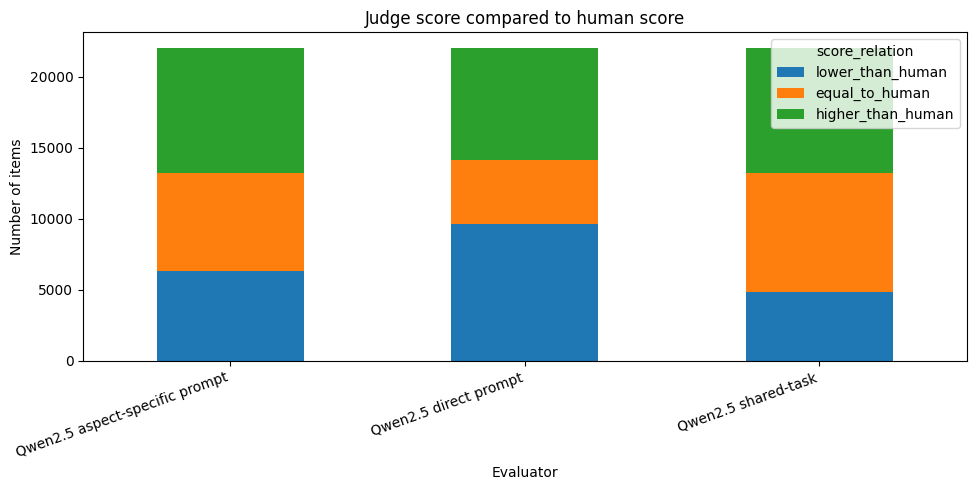

In [96]:
relation_overall.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Judge score compared to human score")
plt.xlabel("Evaluator")
plt.ylabel("Number of items")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [97]:
relation_by_aspect = (
    df_score_long
    .groupby(["evaluator_label", "aspect", "score_relation"])
    .size()
    .reset_index(name="count")
)

display(relation_by_aspect.head())

,evaluator_label,aspect,score_relation,count
0,Qwen2.5 aspect-specific prompt,coherence,equal_to_human,2105
1,Qwen2.5 aspect-specific prompt,coherence,higher_than_human,2657
2,Qwen2.5 aspect-specific prompt,coherence,lower_than_human,2582
3,Qwen2.5 aspect-specific prompt,instruction_following,equal_to_human,3030
4,Qwen2.5 aspect-specific prompt,instruction_following,higher_than_human,3020


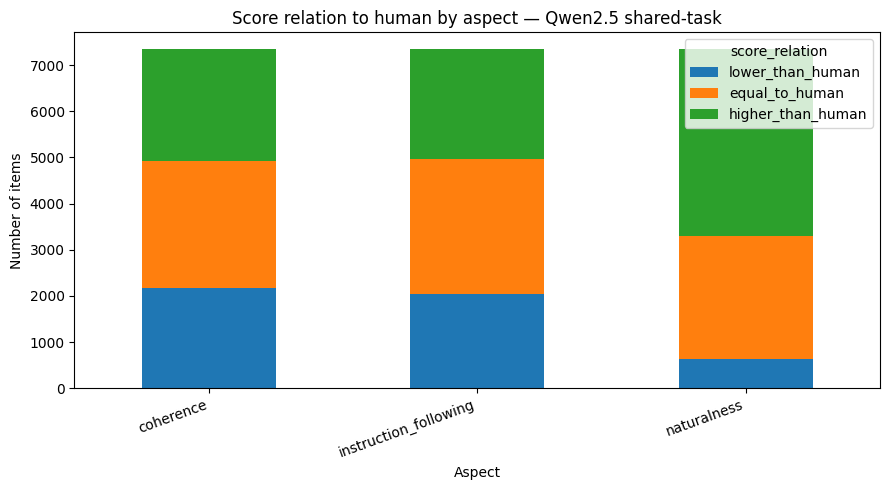

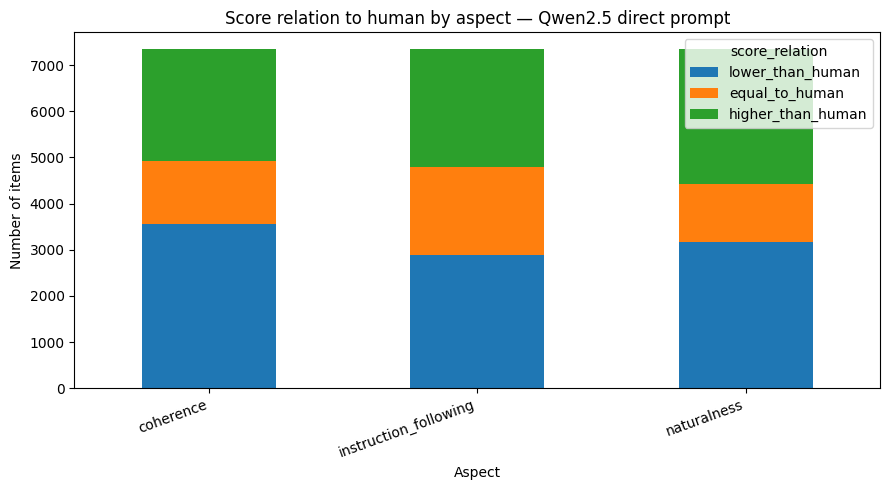

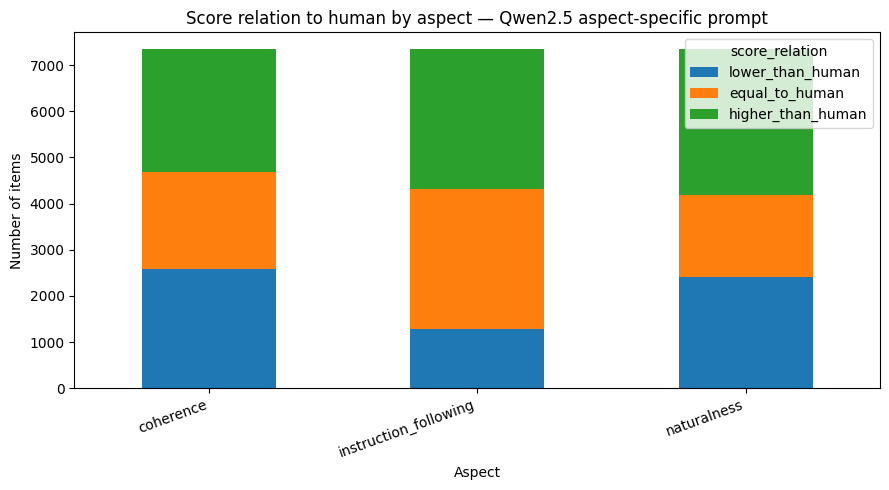

In [98]:
for evaluator in df_score_long["evaluator_label"].unique():
    sub = df_score_long[df_score_long["evaluator_label"] == evaluator]

    table = (
        sub
        .groupby(["aspect", "score_relation"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=relation_order, fill_value=0)
    )

    table.plot(
        kind="bar",
        stacked=True,
        figsize=(9, 5)
    )

    plt.title(f"Score relation to human by aspect — {evaluator}")
    plt.xlabel("Aspect")
    plt.ylabel("Number of items")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

In [99]:
def summarize_score_bias(df, group_cols):
    return (
        df
        .groupby(["evaluator_label"] + group_cols, as_index=False)
        .agg(
            n=("judge_score", "size"),
            human_mean=("human_score", "mean"),
            judge_mean=("judge_score", "mean"),
            mean_diff=("score_diff", "mean"),
            median_diff=("score_diff", "median"),
            std_diff=("score_diff", "std")
        )
    )

In [100]:
bias_overall = summarize_score_bias(df_score_long, [])
display(bias_overall)

,evaluator_label,n,human_mean,judge_mean,mean_diff,median_diff,std_diff
0,Qwen2.5 aspect-specific prompt,22032,5.67352,6.071623,0.398103,0.0,1.649613
1,Qwen2.5 direct prompt,22032,5.67352,5.831563,0.158043,0.0,1.640154
2,Qwen2.5 shared-task,22032,5.67352,6.170615,0.497095,0.0,1.748857


In [101]:
bias_by_aspect = summarize_score_bias(df_score_long, ["aspect"])
display(bias_by_aspect)

,evaluator_label,aspect,n,human_mean,judge_mean,mean_diff,median_diff,std_diff
0,Qwen2.5 aspect-specific prompt,coherence,7344,5.794254,6.099129,0.304875,0.0,1.534140
1,Qwen2.5 aspect-specific prompt,instruction_following,7344,5.874455,6.447712,0.573257,0.0,1.471532
2,Qwen2.5 aspect-specific prompt,naturalness,7344,5.351852,5.668028,0.316176,0.0,1.897189
3,Qwen2.5 direct prompt,coherence,7344,5.794254,5.868736,0.074483,0.0,1.522819
4,Qwen2.5 direct prompt,instruction_following,7344,5.874455,6.068083,0.193627,0.0,1.467922
5,Qwen2.5 direct prompt,naturalness,7344,5.351852,5.557870,0.206019,0.0,1.893864
6,Qwen2.5 shared-task,coherence,7344,5.794254,5.946351,0.152097,0.0,1.631148
7,Qwen2.5 shared-task,instruction_following,7344,5.874455,6.012255,0.137800,0.0,1.594819
8,Qwen2.5 shared-task,naturalness,7344,5.351852,6.553241,1.201389,1.0,1.796661


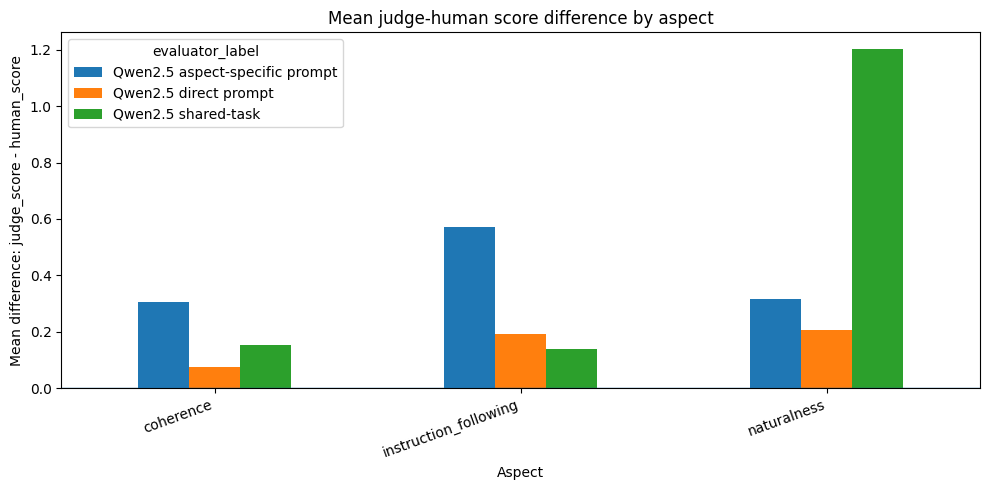

In [102]:
pivot_aspect = bias_by_aspect.pivot(
    index="aspect",
    columns="evaluator_label",
    values="mean_diff"
)

pivot_aspect.plot(kind="bar", figsize=(10, 5))

plt.axhline(0, linewidth=1)
plt.title("Mean judge-human score difference by aspect")
plt.xlabel("Aspect")
plt.ylabel("Mean difference: judge_score - human_score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [103]:
target_language = "English (United States)"

In [104]:
def compute_target_group_bias(
    bias_df,
    group_col,
    target_value,
    value_col="mean_diff"
):
    rows = []

    for evaluator, group in bias_df.groupby("evaluator_label"):
        target_mean = group.loc[
            group[group_col] == target_value,
            value_col
        ].mean()

        non_target_mean = group.loc[
            group[group_col] != target_value,
            value_col
        ].mean()

        rows.append({
            "evaluator_label": evaluator,
            "target_group": target_value,
            "target_mean_diff": target_mean,
            "non_target_mean_diff": non_target_mean,
            "bias_gap": target_mean - non_target_mean,
        })

    return pd.DataFrame(rows)

In [105]:
bias_by_language = summarize_score_bias(df_score_long, ["language_locale"])
display(bias_by_language)

,evaluator_label,language_locale,n,human_mean,judge_mean,mean_diff,median_diff,std_diff
0,Qwen2.5 aspect-specific prompt,Bangla (Bangladesh),2208,3.756341,5.677083,1.920743,2.0,1.625735
1,Qwen2.5 aspect-specific prompt,Czech (Czechia),2208,5.624094,6.130435,0.506341,0.0,1.445884
2,Qwen2.5 aspect-specific prompt,Egyptian Arabic,2160,4.878704,5.816667,0.937963,0.0,1.971977
3,Qwen2.5 aspect-specific prompt,English (United States),2208,6.341938,6.181159,-0.160779,0.0,1.222046
4,Qwen2.5 aspect-specific prompt,German (Germany),2208,6.321105,6.254076,-0.067029,0.0,1.268288
5,Qwen2.5 aspect-specific prompt,Hindi (India),2208,5.805254,5.903533,0.098279,0.0,1.545515
6,Qwen2.5 aspect-specific prompt,Indonesian (Indonesia),2208,6.019022,6.184330,0.165308,0.0,1.482822
7,Qwen2.5 aspect-specific prompt,Japanese (Japan),2208,5.649457,6.197464,0.548007,0.0,1.762381
8,Qwen2.5 aspect-specific prompt,Russian (Russia),2208,6.266757,6.190217,-0.076540,0.0,1.339184
9,Qwen2.5 aspect-specific prompt,Simplified Chinese (China),2208,6.055254,6.175725,0.120471,0.0,1.556656


In [106]:
english_bias = compute_target_group_bias(
    bias_by_language,
    group_col="language_locale",
    target_value=target_language
)

display(english_bias)

,evaluator_label,target_group,target_mean_diff,non_target_mean_diff,bias_gap
0,Qwen2.5 aspect-specific prompt,English (United States),-0.160779,0.461505,-0.622284
1,Qwen2.5 direct prompt,English (United States),-0.697011,0.255065,-0.952076
2,Qwen2.5 shared-task,English (United States),-0.024004,0.556668,-0.580672


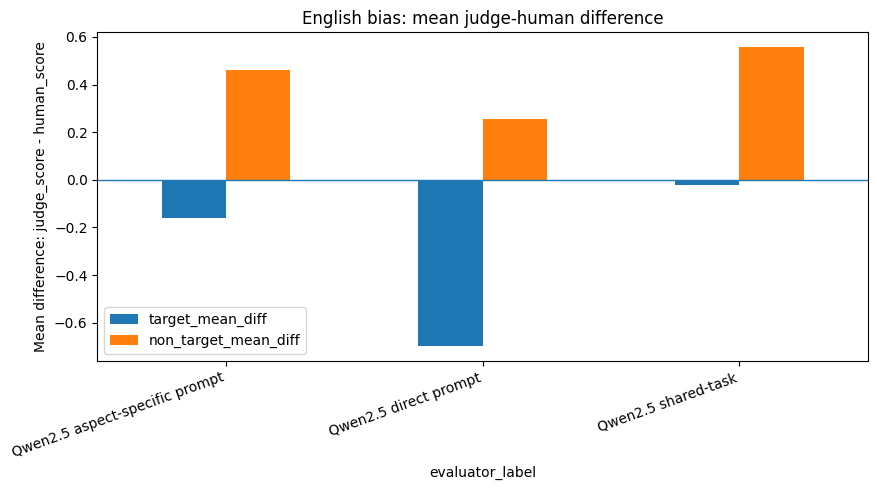

In [107]:
english_bias.set_index("evaluator_label")[
    ["target_mean_diff", "non_target_mean_diff"]
].plot(kind="bar", figsize=(9, 5))

plt.axhline(0, linewidth=1)
plt.title("English bias: mean judge-human difference")
plt.ylabel("Mean difference: judge_score - human_score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

The English bias analysis does not indicate an English over-scoring tendency. Instead, all three Qwen2.5-based evaluators assign lower judge-human differences to English than to non-English data. The direct prompt shows the strongest imbalance, substantially under-scoring English while still over-scoring non-English responses. The aspect-specific prompt reduces this English under-scoring compared to the direct prompt, suggesting better calibration for English, although it still tends to over-score non-English responses. Overall, the observed bias is better described as non-English over-scoring relative to human judgments rather than English favoritism.

In [108]:
score_cols = [
    "shared_task_qwen25",
    "direct_prompt",
    "aspect_specific_prompt"
]

evaluator_name_map = {
    "shared_task_qwen25": "Qwen2.5 shared-task",
    "direct_prompt": "Qwen2.5 direct prompt",
    "aspect_specific_prompt": "Qwen2.5 aspect-specific prompt",
}

keys = ["doc_id", "system", "language_locale", "aspect"]
item_cols = ["doc_id", "language_locale", "aspect"]

In [109]:
system_count_check = (
    df_score_wide_common
    .groupby(item_cols)["system"]
    .nunique()
    .value_counts()
    .sort_index()
)

display(system_count_check)

,count
system,
16,1377


In [110]:
pairwise_item_results = []

for score_col in score_cols:
    df_eval = (
        df_score_wide_common[
            keys + ["human_score", score_col]
        ]
        .dropna(subset=["human_score", score_col])
        .rename(columns={score_col: "judge_score"})
        .copy()
    )

    result = compute_system_pairwise_accuracy(
        df=df_eval,
        group_cols=item_cols,
        system_col="system",
        human_col="human_score",
        judge_col="judge_score",
        tie_threshold=0.0,
    )

    result["evaluator"] = score_col
    result["evaluator_label"] = evaluator_name_map[score_col]

    pairwise_item_results.append(result)

pairwise_item_df = pd.concat(pairwise_item_results, ignore_index=True)

print(pairwise_item_df.shape)
display(pairwise_item_df.head())

(4131, 9)


,doc_id,language_locale,aspect,pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored,evaluator,evaluator_label
0,0a3da1ceeb83f664b813bb28f001d766,Bangla (Bangladesh),coherence,0.192308,15,78,42,shared_task_qwen25,Qwen2.5 shared-task
1,0a3da1ceeb83f664b813bb28f001d766,Bangla (Bangladesh),instruction_following,0.277108,23,83,37,shared_task_qwen25,Qwen2.5 shared-task
2,0a3da1ceeb83f664b813bb28f001d766,Bangla (Bangladesh),naturalness,0.486111,35,72,48,shared_task_qwen25,Qwen2.5 shared-task
3,0a3da1ceeb83f664b813bb28f001d766,Czech (Czechia),coherence,0.325843,29,89,31,shared_task_qwen25,Qwen2.5 shared-task
4,0a3da1ceeb83f664b813bb28f001d766,Czech (Czechia),instruction_following,0.264706,27,102,18,shared_task_qwen25,Qwen2.5 shared-task


In [111]:
def summarize_pairwise_from_items(df, group_cols=None):
    if group_cols is None:
        group_cols = []

    summary = (
        df
        .groupby(["evaluator_label"] + group_cols, as_index=False)
        .agg(
            correct_pairs=("correct_pairs", "sum"),
            n_pairs=("n_pairs", "sum"),
            human_ties_ignored=("human_ties_ignored", "sum"),
            n_items=("pairwise_accuracy", "size"),
        )
    )

    summary["pairwise_accuracy"] = (
        summary["correct_pairs"] / summary["n_pairs"]
    )

    return summary

In [112]:
pairwise_overall = summarize_pairwise_from_items(pairwise_item_df)
display(pairwise_overall)

,evaluator_label,correct_pairs,n_pairs,human_ties_ignored,n_items,pairwise_accuracy
0,Qwen2.5 aspect-specific prompt,29483,82793,82447,1377,0.356105
1,Qwen2.5 direct prompt,21134,82793,82447,1377,0.255263
2,Qwen2.5 shared-task,21441,82793,82447,1377,0.258971


In [113]:
pairwise_by_aspect = summarize_pairwise_from_items(
    pairwise_item_df,
    group_cols=["aspect"]
)

display(pairwise_by_aspect)

,evaluator_label,aspect,correct_pairs,n_pairs,human_ties_ignored,n_items,pairwise_accuracy
0,Qwen2.5 aspect-specific prompt,coherence,9235,26536,28544,459,0.348018
1,Qwen2.5 aspect-specific prompt,instruction_following,8184,25236,29844,459,0.324299
2,Qwen2.5 aspect-specific prompt,naturalness,12064,31021,24059,459,0.388898
3,Qwen2.5 direct prompt,coherence,6118,26536,28544,459,0.230555
4,Qwen2.5 direct prompt,instruction_following,6725,25236,29844,459,0.266484
5,Qwen2.5 direct prompt,naturalness,8291,31021,24059,459,0.267271
6,Qwen2.5 shared-task,coherence,6670,26536,28544,459,0.251357
7,Qwen2.5 shared-task,instruction_following,7728,25236,29844,459,0.306229
8,Qwen2.5 shared-task,naturalness,7043,31021,24059,459,0.227040


In [114]:
pairwise_by_language = summarize_pairwise_from_items(
    pairwise_item_df,
    group_cols=["language_locale"]
)

display(pairwise_by_language)

,evaluator_label,language_locale,correct_pairs,n_pairs,human_ties_ignored,n_items,pairwise_accuracy
0,Qwen2.5 aspect-specific prompt,Bangla (Bangladesh),5050,11362,5198,138,0.444464
1,Qwen2.5 aspect-specific prompt,Czech (Czechia),3360,11065,5495,138,0.303660
2,Qwen2.5 aspect-specific prompt,Egyptian Arabic,3798,8039,8161,135,0.472447
3,Qwen2.5 aspect-specific prompt,English (United States),1455,5333,11227,138,0.272830
4,Qwen2.5 aspect-specific prompt,German (Germany),1832,7280,9280,138,0.251648
5,Qwen2.5 aspect-specific prompt,Hindi (India),3405,7525,9035,138,0.452492
6,Qwen2.5 aspect-specific prompt,Indonesian (Indonesia),2821,9319,7241,138,0.302715
7,Qwen2.5 aspect-specific prompt,Japanese (Japan),3206,9537,7023,138,0.336164
8,Qwen2.5 aspect-specific prompt,Russian (Russia),2575,7542,9018,138,0.341421
9,Qwen2.5 aspect-specific prompt,Simplified Chinese (China),1981,5791,10769,138,0.342083


In [115]:
acceq_item_results = []

for score_col in score_cols:
    df_eval = (
        df_score_wide_common[
            keys + ["human_score", score_col]
        ]
        .dropna(subset=["human_score", score_col])
        .rename(columns={score_col: "judge_score"})
        .copy()
    )

    result = compute_acceq_by_item(
        df=df_eval,
        item_cols=item_cols,
        system_col="system",
        human_col="human_score",
        judge_col="judge_score",
        human_tie_threshold=0.0,
        judge_tie_threshold=0.0,
    )

    result["evaluator"] = score_col
    result["evaluator_label"] = evaluator_name_map[score_col]

    acceq_item_results.append(result)

acceq_item_df = pd.concat(acceq_item_results, ignore_index=True)

print(acceq_item_df.shape)
display(acceq_item_df.head())

(4131, 12)


,doc_id,language_locale,aspect,acceq,C,D,T_h,T_m,T_hm,n_pairs,evaluator,evaluator_label
0,0a3da1ceeb83f664b813bb28f001d766,Bangla (Bangladesh),coherence,0.475000,15,0,0,63,42,120,shared_task_qwen25,Qwen2.5 shared-task
1,0a3da1ceeb83f664b813bb28f001d766,Bangla (Bangladesh),instruction_following,0.450000,23,0,6,60,31,120,shared_task_qwen25,Qwen2.5 shared-task
2,0a3da1ceeb83f664b813bb28f001d766,Bangla (Bangladesh),naturalness,0.541667,35,6,18,31,30,120,shared_task_qwen25,Qwen2.5 shared-task
3,0a3da1ceeb83f664b813bb28f001d766,Czech (Czechia),coherence,0.425000,29,10,9,50,22,120,shared_task_qwen25,Qwen2.5 shared-task
4,0a3da1ceeb83f664b813bb28f001d766,Czech (Czechia),instruction_following,0.275000,27,26,12,49,6,120,shared_task_qwen25,Qwen2.5 shared-task


In [116]:
def summarize_acceq_from_items(df, group_cols=None):
    if group_cols is None:
        group_cols = []

    summary = (
        df
        .groupby(["evaluator_label"] + group_cols, as_index=False)
        .agg(
            C=("C", "sum"),
            D=("D", "sum"),
            T_h=("T_h", "sum"),
            T_m=("T_m", "sum"),
            T_hm=("T_hm", "sum"),
            n_pairs=("n_pairs", "sum"),
            n_items=("acceq", "size"),
        )
    )

    summary["acceq"] = (
        summary["C"] + summary["T_hm"]
    ) / summary["n_pairs"]

    return summary

In [117]:
acceq_overall = summarize_acceq_from_items(acceq_item_df)
display(acceq_overall)

,evaluator_label,C,D,T_h,T_m,T_hm,n_pairs,n_items,acceq
0,Qwen2.5 aspect-specific prompt,29483,12679,32995,40631,49452,165240,1377,0.477699
1,Qwen2.5 direct prompt,21134,9068,24450,52591,57997,165240,1377,0.478885
2,Qwen2.5 shared-task,21441,9453,25148,51899,57299,165240,1377,0.476519


In [118]:
acceq_by_aspect = summarize_acceq_from_items(
    acceq_item_df,
    group_cols=["aspect"]
)

display(acceq_by_aspect)

,evaluator_label,aspect,C,D,T_h,T_m,T_hm,n_pairs,n_items,acceq
0,Qwen2.5 aspect-specific prompt,coherence,9235,3669,11304,13632,17240,55080,459,0.480664
1,Qwen2.5 aspect-specific prompt,instruction_following,8184,3268,9586,13784,20258,55080,459,0.516376
2,Qwen2.5 aspect-specific prompt,naturalness,12064,5742,12105,13215,11954,55080,459,0.436057
3,Qwen2.5 direct prompt,coherence,6118,2092,6338,18326,22206,55080,459,0.514234
4,Qwen2.5 direct prompt,instruction_following,6725,3116,9696,15395,20148,55080,459,0.487890
5,Qwen2.5 direct prompt,naturalness,8291,3860,8416,18870,15643,55080,459,0.434532
6,Qwen2.5 shared-task,coherence,6670,3258,8788,16608,19756,55080,459,0.479775
7,Qwen2.5 shared-task,instruction_following,7728,3398,10791,14110,19053,55080,459,0.486220
8,Qwen2.5 shared-task,naturalness,7043,2797,5569,21181,18490,55080,459,0.463562


In [119]:
acceq_by_language = summarize_acceq_from_items(
    acceq_item_df,
    group_cols=["language_locale"]
)

display(acceq_by_language)

,evaluator_label,language_locale,C,D,T_h,T_m,T_hm,n_pairs,n_items,acceq
0,Qwen2.5 aspect-specific prompt,Bangla (Bangladesh),5050,1789,2686,4523,2512,16560,138,0.456643
1,Qwen2.5 aspect-specific prompt,Czech (Czechia),3360,1712,2160,5993,3335,16560,138,0.404287
2,Qwen2.5 aspect-specific prompt,Egyptian Arabic,3798,979,3515,3262,4646,16200,135,0.521235
3,Qwen2.5 aspect-specific prompt,English (United States),1455,796,3899,3082,7328,16560,138,0.530374
4,Qwen2.5 aspect-specific prompt,German (Germany),1832,1126,3276,4322,6004,16560,138,0.473188
5,Qwen2.5 aspect-specific prompt,Hindi (India),3405,971,3900,3149,5135,16560,138,0.515700
6,Qwen2.5 aspect-specific prompt,Indonesian (Indonesia),2821,1484,2828,5014,4413,16560,138,0.436836
7,Qwen2.5 aspect-specific prompt,Japanese (Japan),3206,1468,2803,4863,4220,16560,138,0.448430
8,Qwen2.5 aspect-specific prompt,Russian (Russia),2575,1294,3257,3673,5761,16560,138,0.503382
9,Qwen2.5 aspect-specific prompt,Simplified Chinese (China),1981,1060,4671,2750,6098,16560,138,0.487862


In [120]:
metrics_overall = pairwise_overall.merge(
    acceq_overall[
        ["evaluator_label", "C", "D", "T_h", "T_m", "T_hm", "n_pairs", "acceq"]
    ],
    on="evaluator_label",
    suffixes=("_pairwise", "_acceq")
)

display(metrics_overall)

,evaluator_label,correct_pairs,n_pairs_pairwise,human_ties_ignored,n_items,pairwise_accuracy,C,D,T_h,T_m,T_hm,n_pairs_acceq,acceq
0,Qwen2.5 aspect-specific prompt,29483,82793,82447,1377,0.356105,29483,12679,32995,40631,49452,165240,0.477699
1,Qwen2.5 direct prompt,21134,82793,82447,1377,0.255263,21134,9068,24450,52591,57997,165240,0.478885
2,Qwen2.5 shared-task,21441,82793,82447,1377,0.258971,21441,9453,25148,51899,57299,165240,0.476519


The aspect-specific prompt performs best for pairwise system ranking. It achieves the highest overall pairwise accuracy (0.356), clearly outperforming both the direct prompt (0.255) and the shared-task Qwen2.5 judge (0.259). This improvement appears consistently across all aspects, especially for naturalness.

However, ACCEQ is almost the same across all three evaluators. The direct prompt is slightly higher in ACCEQ, but this seems mainly due to more tie agreements rather than better ranking ability.

Overall, the aspect-specific prompt improves the judge’s ability to choose the human-preferred system, while tie calibration remains largely unchanged.

In [121]:
metrics_by_aspect = pairwise_by_aspect.merge(
    acceq_by_aspect[
        ["evaluator_label", "aspect", "C", "D", "T_h", "T_m", "T_hm", "n_pairs", "acceq"]
    ],
    on=["evaluator_label", "aspect"],
    suffixes=("_pairwise", "_acceq")
)

display(metrics_by_aspect)

,evaluator_label,aspect,correct_pairs,n_pairs_pairwise,human_ties_ignored,n_items,pairwise_accuracy,C,D,T_h,T_m,T_hm,n_pairs_acceq,acceq
0,Qwen2.5 aspect-specific prompt,coherence,9235,26536,28544,459,0.348018,9235,3669,11304,13632,17240,55080,0.480664
1,Qwen2.5 aspect-specific prompt,instruction_following,8184,25236,29844,459,0.324299,8184,3268,9586,13784,20258,55080,0.516376
2,Qwen2.5 aspect-specific prompt,naturalness,12064,31021,24059,459,0.388898,12064,5742,12105,13215,11954,55080,0.436057
3,Qwen2.5 direct prompt,coherence,6118,26536,28544,459,0.230555,6118,2092,6338,18326,22206,55080,0.514234
4,Qwen2.5 direct prompt,instruction_following,6725,25236,29844,459,0.266484,6725,3116,9696,15395,20148,55080,0.487890
5,Qwen2.5 direct prompt,naturalness,8291,31021,24059,459,0.267271,8291,3860,8416,18870,15643,55080,0.434532
6,Qwen2.5 shared-task,coherence,6670,26536,28544,459,0.251357,6670,3258,8788,16608,19756,55080,0.479775
7,Qwen2.5 shared-task,instruction_following,7728,25236,29844,459,0.306229,7728,3398,10791,14110,19053,55080,0.486220
8,Qwen2.5 shared-task,naturalness,7043,31021,24059,459,0.227040,7043,2797,5569,21181,18490,55080,0.463562


In [122]:
metrics_by_language = pairwise_by_language.merge(
    acceq_by_language[
        ["evaluator_label", "language_locale", "C", "D", "T_h", "T_m", "T_hm", "n_pairs", "acceq"]
    ],
    on=["evaluator_label", "language_locale"],
    suffixes=("_pairwise", "_acceq")
)

display(metrics_by_language)

,evaluator_label,language_locale,correct_pairs,n_pairs_pairwise,human_ties_ignored,n_items,pairwise_accuracy,C,D,T_h,T_m,T_hm,n_pairs_acceq,acceq
0,Qwen2.5 aspect-specific prompt,Bangla (Bangladesh),5050,11362,5198,138,0.444464,5050,1789,2686,4523,2512,16560,0.456643
1,Qwen2.5 aspect-specific prompt,Czech (Czechia),3360,11065,5495,138,0.303660,3360,1712,2160,5993,3335,16560,0.404287
2,Qwen2.5 aspect-specific prompt,Egyptian Arabic,3798,8039,8161,135,0.472447,3798,979,3515,3262,4646,16200,0.521235
3,Qwen2.5 aspect-specific prompt,English (United States),1455,5333,11227,138,0.272830,1455,796,3899,3082,7328,16560,0.530374
4,Qwen2.5 aspect-specific prompt,German (Germany),1832,7280,9280,138,0.251648,1832,1126,3276,4322,6004,16560,0.473188
5,Qwen2.5 aspect-specific prompt,Hindi (India),3405,7525,9035,138,0.452492,3405,971,3900,3149,5135,16560,0.515700
6,Qwen2.5 aspect-specific prompt,Indonesian (Indonesia),2821,9319,7241,138,0.302715,2821,1484,2828,5014,4413,16560,0.436836
7,Qwen2.5 aspect-specific prompt,Japanese (Japan),3206,9537,7023,138,0.336164,3206,1468,2803,4863,4220,16560,0.448430
8,Qwen2.5 aspect-specific prompt,Russian (Russia),2575,7542,9018,138,0.341421,2575,1294,3257,3673,5761,16560,0.503382
9,Qwen2.5 aspect-specific prompt,Simplified Chinese (China),1981,5791,10769,138,0.342083,1981,1060,4671,2750,6098,16560,0.487862


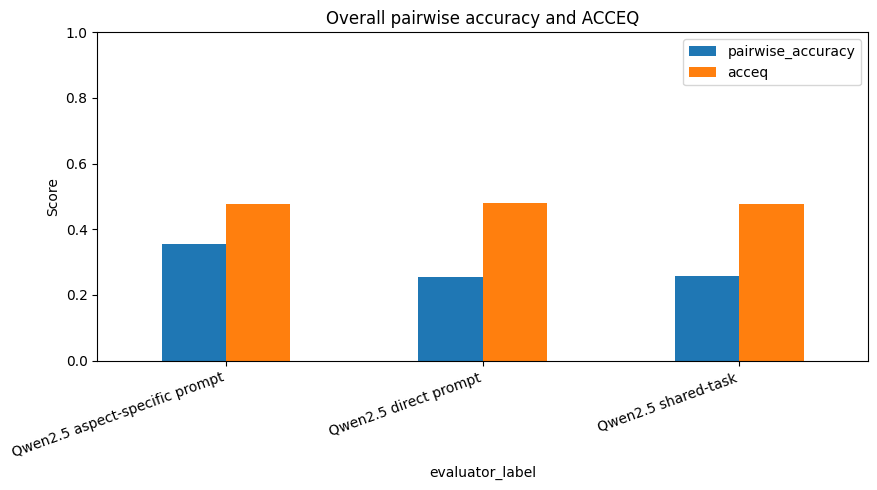

In [123]:
overall_plot = metrics_overall.set_index("evaluator_label")[
    ["pairwise_accuracy", "acceq"]
]

overall_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Overall pairwise accuracy and ACCEQ")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

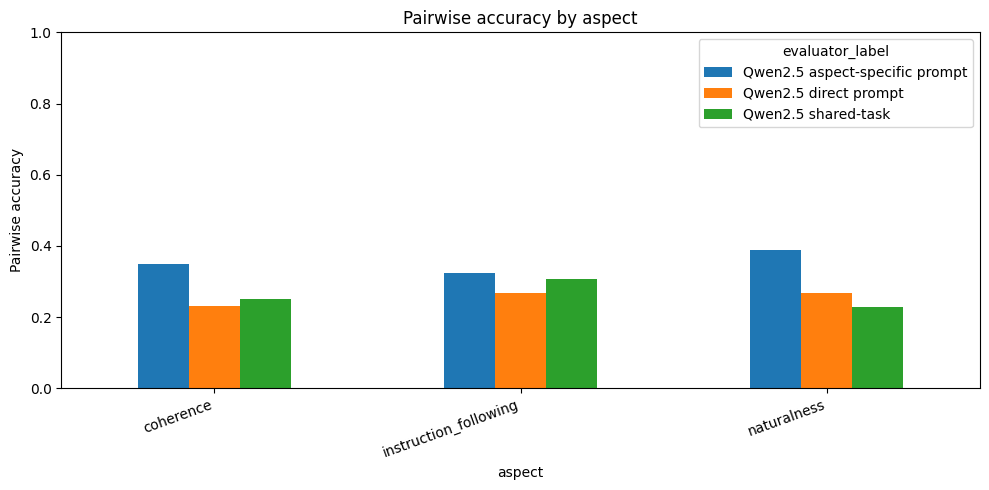

In [124]:
pivot_aspect_pairwise = metrics_by_aspect.pivot(
    index="aspect",
    columns="evaluator_label",
    values="pairwise_accuracy"
)

pivot_aspect_pairwise.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Pairwise accuracy by aspect")
plt.ylabel("Pairwise accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

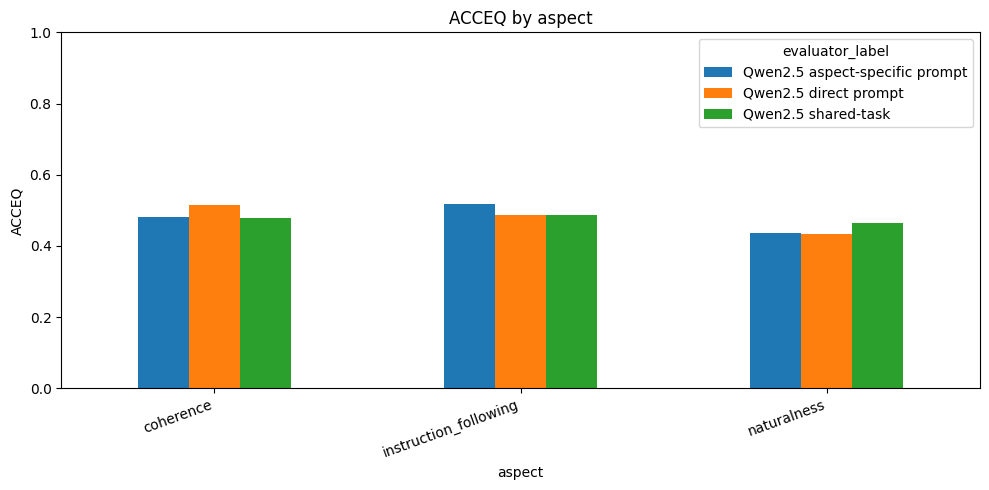

In [125]:
pivot_aspect_acceq = metrics_by_aspect.pivot(
    index="aspect",
    columns="evaluator_label",
    values="acceq"
)

pivot_aspect_acceq.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("ACCEQ by aspect")
plt.ylabel("ACCEQ")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

##Week 8:test on large model




In [126]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from itertools import combinations

PROJECT_ROOT = Path("/content/llm-as-a-judge-praktikum")
WMT_ROOT = Path("/content/wmt-mist")
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

ASPECTS = ["coherence", "naturalness", "instruction_following"]

KEYS_WITH_SEGMENT = [
    "doc_id",
    "segment_id",
    "system",
    "language_locale",
    "aspect",
]

KEYS_NO_SEGMENT = [
    "doc_id",
    "system",
    "language_locale",
    "aspect",
]

In [127]:
human_path = WMT_ROOT / "data/humeval/oeg.json"

mist_candidates = [
    WMT_ROOT / "data/mist_25.json",
    WMT_ROOT / "data/mist/oeg.json",
]

mist_path = next((p for p in mist_candidates if p.exists()), None)
if mist_path is None:
    raise FileNotFoundError("Cannot find mist_25.json or data/mist/oeg.json")

with open(human_path, "r", encoding="utf-8") as f:
    human_data = json.load(f)

with open(mist_path, "r", encoding="utf-8") as f:
    mist_data = json.load(f)

df_human = pd.DataFrame(human_data)
df_mist = pd.DataFrame(mist_data)

df_mist_oeg = df_mist[
    df_mist["taskid"].str.startswith("open_ended_generation", na=False)
].copy()

prefix = "open_ended_generation_"
df_mist_oeg["doc_segment"] = df_mist_oeg["taskid"].str.replace(
    prefix, "", regex=False
)

df_mist_oeg["doc_id"] = df_mist_oeg["doc_segment"].str.rsplit("_", n=1).str[0]
df_mist_oeg["segment_id"] = df_mist_oeg["doc_segment"].str.rsplit("_", n=1).str[1]

df_segment_map = df_mist_oeg[
    ["doc_id", "segment_id", "prompt"]
].drop_duplicates()

df_human_with_segment = df_human.merge(
    df_segment_map,
    on=["doc_id", "prompt"],
    how="left",
)

print("Missing segment_id:", df_human_with_segment["segment_id"].isna().sum())

df_human_clean = df_human_with_segment.dropna(subset=["segment_id"]).copy()
df_human_clean["segment_id"] = df_human_clean["segment_id"].astype(int).astype(str)

df_human_long_deepseek = df_human_clean.melt(
    id_vars=[
        "doc_id",
        "segment_id",
        "system",
        "language",
        "language_locale",
        "prompt",
        "response",
    ],
    value_vars=ASPECTS,
    var_name="aspect",
    value_name="human_score",
)

human_base = (
    df_human_long_deepseek[
        KEYS_WITH_SEGMENT + ["human_score"]
    ]
    .drop_duplicates(KEYS_WITH_SEGMENT)
    .copy()
)

print("human_base shape:", human_base.shape)
display(human_base.head())

Missing segment_id: 16
human_base shape: (22032, 6)


,doc_id,segment_id,system,language_locale,aspect,human_score
0,104373856e995a074579797ebe34fcb2,293,Gemma-3-12B,Egyptian Arabic,coherence,7.0
1,e91353a8c4dde03994b2cbfb5521172e,298,Mistral-Medium,Egyptian Arabic,coherence,5.0
2,170d490a7ae53347e8fe3eabe4e28001,288,Qwen3-235B,Egyptian Arabic,coherence,7.0
3,14e076d13751e87d8c09f7f13125e755,241,CommandR7B,Egyptian Arabic,coherence,7.0
4,c145f96bc4b6c5d0d18e06e89cb629bd,210,Llama-3,Egyptian Arabic,coherence,5.0


In [128]:
def load_prompt_scores(path, score_col_name):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    required = KEYS_NO_SEGMENT + ["judge_score"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{path.name} is missing columns: {missing}")

    df = df[required].copy()
    df["aspect"] = df["aspect"].astype(str).str.strip()
    df["judge_score"] = pd.to_numeric(df["judge_score"], errors="coerce")

    df = df[
        df["aspect"].isin(ASPECTS)
    ].dropna(subset=KEYS_NO_SEGMENT + ["judge_score"])

    # Nếu vì lý do nào đó có duplicate key, lấy mean để không làm nở bảng khi merge.
    df = (
        df.groupby(KEYS_NO_SEGMENT, as_index=False)["judge_score"]
        .mean()
        .rename(columns={"judge_score": score_col_name})
    )

    return df


direct_deepseek = load_prompt_scores(
    RESULTS_DIR / "openrouter_direct_prompt_full_deepseek.csv",
    "direct_prompt",
)

aspect_deepseek = load_prompt_scores(
    RESULTS_DIR / "openrouter_aspect_specific_prompt_full_deepseek.csv",
    "aspect_specific_prompt",
)

print("direct_deepseek:", direct_deepseek.shape)
print("aspect_deepseek:", aspect_deepseek.shape)

display(direct_deepseek.head())
display(aspect_deepseek.head())

direct_deepseek: (22038, 5)
aspect_deepseek: (22043, 5)


,doc_id,system,language_locale,aspect,direct_prompt
0,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),coherence,4.0
1,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),instruction_following,3.0
2,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),naturalness,4.0
3,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),coherence,6.0
4,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),instruction_following,6.0


,doc_id,system,language_locale,aspect,aspect_specific_prompt
0,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),coherence,3.0
1,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),instruction_following,5.0
2,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Bangla (Bangladesh),naturalness,3.0
3,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),coherence,6.0
4,0a3da1ceeb83f664b813bb28f001d766,AyaExpanse-32B,Czech (Czechia),instruction_following,7.0


In [129]:
def get_shared_task_deepseek():
    if "df_deepseek_v3_merged" in globals():
        df = df_deepseek_v3_merged.copy()
        print("Using df_deepseek_v3_merged")
    elif "all_merged" in globals():
        df = all_merged[
            all_merged["judge_model"]
            .astype(str)
            .str.contains("deepseek", case=False, na=False)
        ].copy()
        print("Using all_merged filtered by DeepSeek")
    else:
        raise NameError(
            "Please run the earlier shared-task merge cells first, "
            "so that df_deepseek_v3_merged or all_merged exists."
        )

    required = KEYS_WITH_SEGMENT + ["judge_score"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Shared-task DeepSeek table is missing columns: {missing}")

    df = df[required].copy()
    df["segment_id"] = df["segment_id"].astype(int).astype(str)
    df["aspect"] = df["aspect"].astype(str).str.strip()
    df["judge_score"] = pd.to_numeric(df["judge_score"], errors="coerce")

    df = df[
        df["aspect"].isin(ASPECTS)
    ].dropna(subset=KEYS_WITH_SEGMENT + ["judge_score"])

    df = (
        df.groupby(KEYS_WITH_SEGMENT, as_index=False)["judge_score"]
        .mean()
        .rename(columns={"judge_score": "shared_task_deepseek"})
    )

    return df


shared_deepseek = get_shared_task_deepseek()

print("shared_deepseek:", shared_deepseek.shape)
display(shared_deepseek.head())

Using df_deepseek_v3_merged
shared_deepseek: (22032, 6)


,doc_id,segment_id,system,language_locale,aspect,shared_task_deepseek
0,0a3da1ceeb83f664b813bb28f001d766,1170,AyaExpanse-32B,Indonesian (Indonesia),coherence,7.0
1,0a3da1ceeb83f664b813bb28f001d766,1170,AyaExpanse-32B,Indonesian (Indonesia),instruction_following,7.0
2,0a3da1ceeb83f664b813bb28f001d766,1170,AyaExpanse-32B,Indonesian (Indonesia),naturalness,7.0
3,0a3da1ceeb83f664b813bb28f001d766,1170,AyaExpanse-8B,Indonesian (Indonesia),coherence,7.0
4,0a3da1ceeb83f664b813bb28f001d766,1170,AyaExpanse-8B,Indonesian (Indonesia),instruction_following,7.0


In [130]:
deepseek_score_wide = (
    human_base
    .merge(
        direct_deepseek,
        on=KEYS_NO_SEGMENT,
        how="left",
    )
    .merge(
        aspect_deepseek,
        on=KEYS_NO_SEGMENT,
        how="left",
    )
    .merge(
        shared_deepseek,
        on=KEYS_WITH_SEGMENT,
        how="left",
    )
)

score_cols = [
    "shared_task_deepseek",
    "direct_prompt",
    "aspect_specific_prompt",
]

print("wide shape:", deepseek_score_wide.shape)

missing_summary = deepseek_score_wide[score_cols].isna().sum()
display(missing_summary)

deepseek_score_wide_common = deepseek_score_wide.dropna(
    subset=["human_score"] + score_cols
).copy()

print("common wide shape:", deepseek_score_wide_common.shape)

display(deepseek_score_wide_common.head())

wide shape: (22032, 9)


,0
shared_task_deepseek,0
direct_prompt,42
aspect_specific_prompt,37


common wide shape: (21974, 9)


,doc_id,segment_id,system,language_locale,aspect,human_score,direct_prompt,aspect_specific_prompt,shared_task_deepseek
0,104373856e995a074579797ebe34fcb2,293,Gemma-3-12B,Egyptian Arabic,coherence,7.0,6.0,6.0,7.0
1,e91353a8c4dde03994b2cbfb5521172e,298,Mistral-Medium,Egyptian Arabic,coherence,5.0,6.0,6.0,7.0
2,170d490a7ae53347e8fe3eabe4e28001,288,Qwen3-235B,Egyptian Arabic,coherence,7.0,6.0,6.0,7.0
3,14e076d13751e87d8c09f7f13125e755,241,CommandR7B,Egyptian Arabic,coherence,7.0,6.0,6.0,6.0
4,c145f96bc4b6c5d0d18e06e89cb629bd,210,Llama-3,Egyptian Arabic,coherence,5.0,6.0,6.0,7.0


In [131]:
evaluator_name_map = {
    "shared_task_deepseek": "DeepSeek shared-task",
    "direct_prompt": "DeepSeek direct prompt",
    "aspect_specific_prompt": "DeepSeek aspect-specific prompt",
}

deepseek_score_long = deepseek_score_wide_common.melt(
    id_vars=KEYS_WITH_SEGMENT + ["human_score"],
    value_vars=score_cols,
    var_name="evaluator",
    value_name="judge_score",
)

deepseek_score_long["evaluator_label"] = deepseek_score_long["evaluator"].map(
    evaluator_name_map
)

deepseek_score_long["score_diff"] = (
    deepseek_score_long["judge_score"] - deepseek_score_long["human_score"]
)

print("long shape:", deepseek_score_long.shape)
display(deepseek_score_long.head())

long shape: (65922, 10)


,doc_id,segment_id,system,language_locale,aspect,human_score,evaluator,judge_score,evaluator_label,score_diff
0,104373856e995a074579797ebe34fcb2,293,Gemma-3-12B,Egyptian Arabic,coherence,7.0,shared_task_deepseek,7.0,DeepSeek shared-task,0.0
1,e91353a8c4dde03994b2cbfb5521172e,298,Mistral-Medium,Egyptian Arabic,coherence,5.0,shared_task_deepseek,7.0,DeepSeek shared-task,2.0
2,170d490a7ae53347e8fe3eabe4e28001,288,Qwen3-235B,Egyptian Arabic,coherence,7.0,shared_task_deepseek,7.0,DeepSeek shared-task,0.0
3,14e076d13751e87d8c09f7f13125e755,241,CommandR7B,Egyptian Arabic,coherence,7.0,shared_task_deepseek,6.0,DeepSeek shared-task,-1.0
4,c145f96bc4b6c5d0d18e06e89cb629bd,210,Llama-3,Egyptian Arabic,coherence,5.0,shared_task_deepseek,7.0,DeepSeek shared-task,2.0


In [134]:
deepseek_score_wide_common = deepseek_score_wide.dropna(
    subset=["human_score", "shared_task_deepseek", "direct_prompt", "aspect_specific_prompt"]
).copy()

In [135]:
print("Rows removed because of missing prompt scores:",
      len(deepseek_score_wide) - len(deepseek_score_wide_common))

Rows removed because of missing prompt scores: 58


In [137]:
score_cols = [
    "shared_task_deepseek",
    "direct_prompt",
    "aspect_specific_prompt",
]

deepseek_score_wide_common = deepseek_score_wide.dropna(
    subset=["human_score"] + score_cols
).copy()

print("Before dropna:", deepseek_score_wide.shape)
print("After dropna:", deepseek_score_wide_common.shape)
print("Removed rows:", len(deepseek_score_wide) - len(deepseek_score_wide_common))

display(deepseek_score_wide_common[["human_score"] + score_cols].isna().sum())

Before dropna: (22032, 9)
After dropna: (21974, 9)
Removed rows: 58


,0
human_score,0
shared_task_deepseek,0
direct_prompt,0
aspect_specific_prompt,0


In [132]:
def get_relation(score_a, score_b, tie_threshold=0.0):
    diff = score_a - score_b

    if abs(diff) <= tie_threshold:
        return 0
    elif diff > 0:
        return 1
    else:
        return -1


def compute_system_pairwise_accuracy_items(
    df,
    group_cols,
    system_col="system",
    human_col="human_score",
    judge_col="judge_score",
    tie_threshold=0.0,
):
    rows = []

    for group_key, group in df.groupby(group_cols, dropna=False):
        scores = (
            group
            .groupby(system_col, as_index=False)
            .agg(
                human_mean=(human_col, "mean"),
                judge_mean=(judge_col, "mean"),
            )
        )

        correct = 0
        total = 0
        human_ties_ignored = 0

        for a, b in combinations(scores.index, 2):
            h_rel = get_relation(
                scores.loc[a, "human_mean"],
                scores.loc[b, "human_mean"],
                tie_threshold=tie_threshold,
            )

            j_rel = get_relation(
                scores.loc[a, "judge_mean"],
                scores.loc[b, "judge_mean"],
                tie_threshold=tie_threshold,
            )

            # Pairwise accuracy ignores human ties.
            if h_rel == 0:
                human_ties_ignored += 1
                continue

            if h_rel == j_rel:
                correct += 1

            total += 1

        pairwise_accuracy = correct / total if total > 0 else np.nan

        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        row = dict(zip(group_cols, group_key))
        row.update(
            {
                "pairwise_accuracy": pairwise_accuracy,
                "correct_pairs": correct,
                "n_pairs": total,
                "human_ties_ignored": human_ties_ignored,
            }
        )
        rows.append(row)

    return pd.DataFrame(rows)


def compute_acceq_items(
    df,
    group_cols,
    system_col="system",
    human_col="human_score",
    judge_col="judge_score",
    human_tie_threshold=0.0,
    judge_tie_threshold=0.0,
):
    rows = []

    for group_key, group in df.groupby(group_cols, dropna=False):
        scores = (
            group
            .groupby(system_col, as_index=False)
            .agg(
                human_mean=(human_col, "mean"),
                judge_mean=(judge_col, "mean"),
            )
        )

        C = 0       # concordant non-tie
        D = 0       # discordant non-tie
        T_h = 0     # human tie, judge non-tie
        T_m = 0     # human non-tie, judge tie
        T_hm = 0    # both tie

        for a, b in combinations(scores.index, 2):
            h_rel = get_relation(
                scores.loc[a, "human_mean"],
                scores.loc[b, "human_mean"],
                tie_threshold=human_tie_threshold,
            )

            j_rel = get_relation(
                scores.loc[a, "judge_mean"],
                scores.loc[b, "judge_mean"],
                tie_threshold=judge_tie_threshold,
            )

            if h_rel == 0 and j_rel == 0:
                T_hm += 1
            elif h_rel == 0 and j_rel != 0:
                T_h += 1
            elif h_rel != 0 and j_rel == 0:
                T_m += 1
            elif h_rel == j_rel:
                C += 1
            else:
                D += 1

        total = C + D + T_h + T_m + T_hm
        acc_eq = (C + T_hm) / total if total > 0 else np.nan

        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        row = dict(zip(group_cols, group_key))
        row.update(
            {
                "acc_eq": acc_eq,
                "C": C,
                "D": D,
                "T_h": T_h,
                "T_m": T_m,
                "T_hm": T_hm,
                "n_pairs_acceq": total,
            }
        )
        rows.append(row)

    return pd.DataFrame(rows)

In [138]:
item_cols = ["doc_id", "segment_id", "language_locale", "aspect"]

pairwise_item_results = []
acceq_item_results = []

for score_col in score_cols:
    df_eval = (
        deepseek_score_wide_common[
            KEYS_WITH_SEGMENT + ["human_score", score_col]
        ]
        .rename(columns={score_col: "judge_score"})
        .copy()
    )

    print(score_col, df_eval.shape)

    pairwise_items = compute_system_pairwise_accuracy_items(
        df=df_eval,
        group_cols=item_cols,
        system_col="system",
        human_col="human_score",
        judge_col="judge_score",
        tie_threshold=0.0,
    )

    pairwise_items["evaluator"] = score_col
    pairwise_items["evaluator_label"] = evaluator_name_map[score_col]
    pairwise_item_results.append(pairwise_items)

    acceq_items = compute_acceq_items(
        df=df_eval,
        group_cols=item_cols,
        system_col="system",
        human_col="human_score",
        judge_col="judge_score",
        human_tie_threshold=0.0,
        judge_tie_threshold=0.0,
    )

    acceq_items["evaluator"] = score_col
    acceq_items["evaluator_label"] = evaluator_name_map[score_col]
    acceq_item_results.append(acceq_items)


deepseek_pairwise_items = pd.concat(pairwise_item_results, ignore_index=True)
deepseek_acceq_items = pd.concat(acceq_item_results, ignore_index=True)

display(deepseek_pairwise_items.head())
display(deepseek_acceq_items.head())

shared_task_deepseek (21974, 7)
direct_prompt (21974, 7)
aspect_specific_prompt (21974, 7)


,doc_id,segment_id,language_locale,aspect,pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored,evaluator,evaluator_label
0,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),coherence,0.000000,0,93,27,shared_task_deepseek,DeepSeek shared-task
1,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),instruction_following,NaN,0,0,120,shared_task_deepseek,DeepSeek shared-task
2,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),naturalness,0.000000,0,59,61,shared_task_deepseek,DeepSeek shared-task
3,0a3da1ceeb83f664b813bb28f001d766,1370,Japanese (Japan),coherence,0.317073,13,41,79,shared_task_deepseek,DeepSeek shared-task
4,0a3da1ceeb83f664b813bb28f001d766,1370,Japanese (Japan),instruction_following,0.000000,0,73,47,shared_task_deepseek,DeepSeek shared-task


,doc_id,segment_id,language_locale,aspect,acc_eq,C,D,T_h,T_m,T_hm,n_pairs_acceq,evaluator,evaluator_label
0,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),coherence,0.225000,0,0,0,93,27,120,shared_task_deepseek,DeepSeek shared-task
1,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),instruction_following,1.000000,0,0,0,0,120,120,shared_task_deepseek,DeepSeek shared-task
2,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),naturalness,0.508333,0,0,0,59,61,120,shared_task_deepseek,DeepSeek shared-task
3,0a3da1ceeb83f664b813bb28f001d766,1370,Japanese (Japan),coherence,0.758333,13,1,1,27,78,120,shared_task_deepseek,DeepSeek shared-task
4,0a3da1ceeb83f664b813bb28f001d766,1370,Japanese (Japan),instruction_following,0.316667,0,6,9,67,38,120,shared_task_deepseek,DeepSeek shared-task


In [139]:
pairwise_summary = (
    deepseek_pairwise_items
    .groupby(["evaluator", "evaluator_label"], as_index=False)
    .agg(
        correct_pairs=("correct_pairs", "sum"),
        n_pairs=("n_pairs", "sum"),
        human_ties_ignored=("human_ties_ignored", "sum"),
        n_items=("pairwise_accuracy", "size"),
        mean_item_pairwise_accuracy=("pairwise_accuracy", "mean"),
    )
)

pairwise_summary["system_pairwise_accuracy"] = (
    pairwise_summary["correct_pairs"] / pairwise_summary["n_pairs"]
)

acceq_summary = (
    deepseek_acceq_items
    .groupby(["evaluator", "evaluator_label"], as_index=False)
    .agg(
        C=("C", "sum"),
        D=("D", "sum"),
        T_h=("T_h", "sum"),
        T_m=("T_m", "sum"),
        T_hm=("T_hm", "sum"),
        n_pairs_acceq=("n_pairs_acceq", "sum"),
        mean_item_acc_eq=("acc_eq", "mean"),
    )
)

acceq_summary["acc_eq"] = (
    (acceq_summary["C"] + acceq_summary["T_hm"])
    / acceq_summary["n_pairs_acceq"]
)

deepseek_metrics_summary = (
    pairwise_summary
    .merge(acceq_summary, on=["evaluator", "evaluator_label"], how="left")
    .sort_values("acc_eq", ascending=False)
    .reset_index(drop=True)
)

cols_order = [
    "evaluator",
    "evaluator_label",
    "system_pairwise_accuracy",
    "acc_eq",
    "correct_pairs",
    "n_pairs",
    "human_ties_ignored",
    "C",
    "D",
    "T_h",
    "T_m",
    "T_hm",
    "n_pairs_acceq",
    "n_items",
    "mean_item_pairwise_accuracy",
    "mean_item_acc_eq",
]

deepseek_metrics_summary = deepseek_metrics_summary[cols_order]

display(deepseek_metrics_summary)

,evaluator,evaluator_label,system_pairwise_accuracy,acc_eq,correct_pairs,n_pairs,human_ties_ignored,C,D,T_h,T_m,T_hm,n_pairs_acceq,n_items,mean_item_pairwise_accuracy,mean_item_acc_eq
0,shared_task_deepseek,DeepSeek shared-task,0.266752,0.539309,21990,82436,82069,21990,5208,15340,55238,66729,164505,1377,0.271769,0.539510
1,aspect_specific_prompt,DeepSeek aspect-specific prompt,0.374594,0.515699,30880,82436,82069,30880,9180,28114,42376,53955,164505,1377,0.375347,0.515548
2,direct_prompt,DeepSeek direct prompt,0.330014,0.511875,27205,82436,82069,27205,7745,25068,47486,57001,164505,1377,0.334360,0.511733


In [140]:
from itertools import combinations
import numpy as np
import pandas as pd

def get_relation(score_a, score_b, tie_threshold=0.0):
    diff = score_a - score_b

    if abs(diff) <= tie_threshold:
        return 0
    elif diff > 0:
        return 1
    else:
        return -1


def compute_global_system_pairwise_accuracy(
    df,
    system_col="system",
    human_col="human_score",
    judge_col="judge_score",
    tie_threshold=0.0,
):
    # Aggregate toàn bộ dataset về system-level mean
    system_scores = (
        df.groupby(system_col, as_index=False)
        .agg(
            human_mean=(human_col, "mean"),
            judge_mean=(judge_col, "mean"),
            n_rows=(judge_col, "count"),
        )
    )

    correct = 0
    total = 0
    human_ties_ignored = 0

    pair_details = []

    for i, j in combinations(system_scores.index, 2):
        system_a = system_scores.loc[i, system_col]
        system_b = system_scores.loc[j, system_col]

        human_a = system_scores.loc[i, "human_mean"]
        human_b = system_scores.loc[j, "human_mean"]

        judge_a = system_scores.loc[i, "judge_mean"]
        judge_b = system_scores.loc[j, "judge_mean"]

        human_rel = get_relation(human_a, human_b, tie_threshold=tie_threshold)
        judge_rel = get_relation(judge_a, judge_b, tie_threshold=tie_threshold)

        if human_rel == 0:
            human_ties_ignored += 1
            continue

        is_correct = human_rel == judge_rel

        if is_correct:
            correct += 1

        total += 1

        pair_details.append(
            {
                "system_a": system_a,
                "system_b": system_b,
                "human_a": human_a,
                "human_b": human_b,
                "judge_a": judge_a,
                "judge_b": judge_b,
                "human_relation": human_rel,
                "judge_relation": judge_rel,
                "correct": is_correct,
            }
        )

    pairwise_accuracy = correct / total if total > 0 else np.nan

    summary = {
        "system_pairwise_accuracy": pairwise_accuracy,
        "correct_pairs": correct,
        "n_pairs": total,
        "human_ties_ignored": human_ties_ignored,
        "n_systems": system_scores[system_col].nunique(),
    }

    return summary, system_scores, pd.DataFrame(pair_details)

In [141]:
evaluator_name_map = {
    "shared_task_deepseek": "DeepSeek shared-task",
    "direct_prompt": "DeepSeek direct prompt",
    "aspect_specific_prompt": "DeepSeek aspect-specific prompt",
}

global_pairwise_results = []
global_system_scores = {}
global_pair_details = {}

for score_col in score_cols:
    df_eval = (
        deepseek_score_wide_common[
            ["system", "human_score", score_col]
        ]
        .rename(columns={score_col: "judge_score"})
        .copy()
    )

    summary, system_scores, pair_details = compute_global_system_pairwise_accuracy(
        df=df_eval,
        system_col="system",
        human_col="human_score",
        judge_col="judge_score",
        tie_threshold=0.0,
    )

    summary["evaluator"] = score_col
    summary["evaluator_label"] = evaluator_name_map[score_col]

    global_pairwise_results.append(summary)
    global_system_scores[score_col] = system_scores
    global_pair_details[score_col] = pair_details

global_pairwise_summary = pd.DataFrame(global_pairwise_results)

global_pairwise_summary = global_pairwise_summary[
    [
        "evaluator",
        "evaluator_label",
        "system_pairwise_accuracy",
        "correct_pairs",
        "n_pairs",
        "human_ties_ignored",
        "n_systems",
    ]
].sort_values("system_pairwise_accuracy", ascending=False)

display(global_pairwise_summary)

,evaluator,evaluator_label,system_pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored,n_systems
2,aspect_specific_prompt,DeepSeek aspect-specific prompt,0.908333,109,120,0,16
1,direct_prompt,DeepSeek direct prompt,0.866667,104,120,0,16
0,shared_task_deepseek,DeepSeek shared-task,0.858333,103,120,0,16


In [142]:
global_pairwise_by_aspect_results = []

for score_col in score_cols:
    for aspect in sorted(deepseek_score_wide_common["aspect"].unique()):
        df_eval = (
            deepseek_score_wide_common[
                deepseek_score_wide_common["aspect"] == aspect
            ][
                ["system", "human_score", score_col]
            ]
            .rename(columns={score_col: "judge_score"})
            .copy()
        )

        summary, _, _ = compute_global_system_pairwise_accuracy(
            df=df_eval,
            system_col="system",
            human_col="human_score",
            judge_col="judge_score",
            tie_threshold=0.0,
        )

        summary["aspect"] = aspect
        summary["evaluator"] = score_col
        summary["evaluator_label"] = evaluator_name_map[score_col]

        global_pairwise_by_aspect_results.append(summary)

global_pairwise_by_aspect = pd.DataFrame(global_pairwise_by_aspect_results)

global_pairwise_by_aspect = global_pairwise_by_aspect[
    [
        "evaluator",
        "evaluator_label",
        "aspect",
        "system_pairwise_accuracy",
        "correct_pairs",
        "n_pairs",
        "human_ties_ignored",
        "n_systems",
    ]
].sort_values(["aspect", "system_pairwise_accuracy"], ascending=[True, False])

display(global_pairwise_by_aspect)

,evaluator,evaluator_label,aspect,system_pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored,n_systems
6,aspect_specific_prompt,DeepSeek aspect-specific prompt,coherence,0.925000,111,120,0,16
0,shared_task_deepseek,DeepSeek shared-task,coherence,0.841667,101,120,0,16
3,direct_prompt,DeepSeek direct prompt,coherence,0.841667,101,120,0,16
1,shared_task_deepseek,DeepSeek shared-task,instruction_following,0.916667,110,120,0,16
4,direct_prompt,DeepSeek direct prompt,instruction_following,0.891667,107,120,0,16
7,aspect_specific_prompt,DeepSeek aspect-specific prompt,instruction_following,0.891667,107,120,0,16
5,direct_prompt,DeepSeek direct prompt,naturalness,0.841667,101,120,0,16
8,aspect_specific_prompt,DeepSeek aspect-specific prompt,naturalness,0.816667,98,120,0,16
2,shared_task_deepseek,DeepSeek shared-task,naturalness,0.791667,95,120,0,16
